# Survival Analysis Event-Store Workflow — V5

This notebook uses the renamed, verified modules `survival_analysis_basis_eventstore_v5.py` and `survival_analysis_basis_pipeline_v5.py`. It separates chunked event extraction from later monthly, quarterly, annual, or custom-period aggregation.

### Survival Analysis
This file calls the classes and functions declared in survival_analysis.py to fit survival analysis models

The convention used in this file is:
<ul>
    <li>'um': linear perp</li>
    <li>'cm': inverse perp</li>
</ul>

### Parametric Functions

To Do:
- research factors that would affect absorption time
- consider regression results from papers?
- consider limit order variables

To be investigated:
- funding rate
- volatility
- market volumes (spot and perp)
- shock size?

From BitMex paper:
- relative spread (average spread of spot divided by perp spread)
- relative trading volume (total trading volume of spot divided by perp)
- log return (for spot and perp)
- absolute basis (absolute value of average difference of log prices between spot and perp)
- dummy variable for days with negative return, interaction with absolute basis

From limit order paper:
- bid-ask spread, liquidity, volatility, share price, daily volume

From crypto carry paper:
- index for google searches
- crypto returns over past day/week/month
- signed trading volume (volume x returns)

Aggregated variables: (daily)
- spread and relative spread
- trading volume and relative trading volume
- log return for spot and perp (lagged day/week/month)
- absolute basis
- volatility
- index for google searches
- market status?
- indicator for positive/negative return?
- funding rate

It's expected that convergence patterns should be affected by crypto market efficiency in general

Idea:
- pick one convergence/shock combination
- join to covariates (daily)
- fit mixed cox model and parametric models (exponential?)

In [1]:
import datetime
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time
from trade_data_pull import *
from survival_analysis import *

## BTC

#### Kaplan-Meier Plots

In [ ]:
# spot POV (spot to perps)
sa = SurvivalAnalysis('BTCUSDT', 'Binance', 'um')
data_sp, events_sp, shocks_sp = sa.fit_KM('20251201', '20251231', [0.001])

Processing 30 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
Processing 30 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
lee_mykland 3.0 0.99 None 0.0010000000000000009 True spot


In [ ]:
# perp POV (perps to spot)
data_ps, events_ps, shocks_ps = sa.fit_KM('20251201', '20251231', [0.001], first='perp')

Processing 30 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
Processing 30 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
lee_mykland 3.0 0.99 None 0.0010000000000000009 True perp


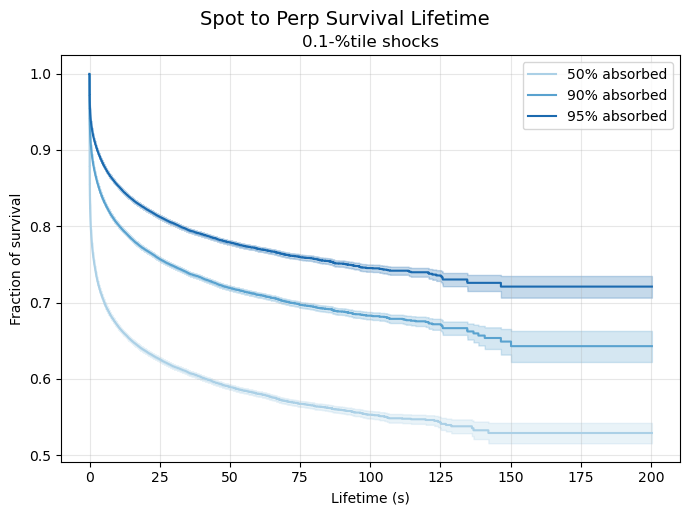

In [6]:
kmfs = sa.graph_results(shocks_sp, [0.001], ncols=1, figsize=(7,5), first='spot')

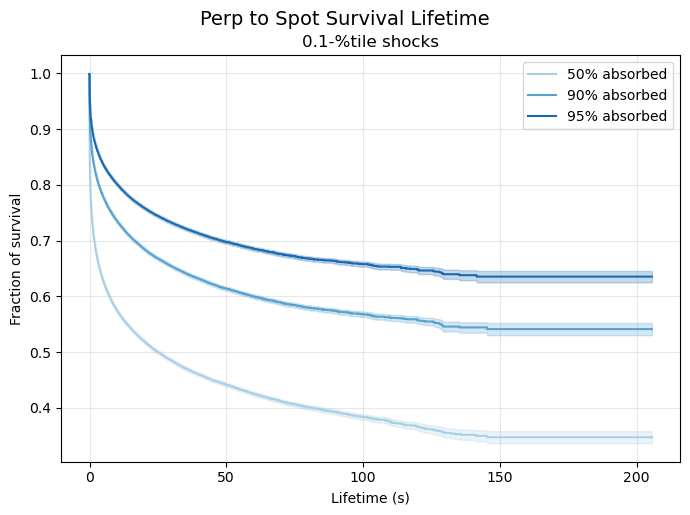

In [11]:
kmfs = sa.graph_results(shocks_ps, [0.001], ncols=1, figsize=(7,5), first='perp')

In [3]:
# sa = SurvivalAnalysis('BTCUSDT')
# # df_ret_joined contains funding rates
# data, df_ret_joined = sa._get_and_parse_data('20210101', '20210201')

Fetching file list from Binance...
Processing 32 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
Using cached file list...
Processing 32 files...
Processing batch 1/2
Processing batch 2/2
Combining results...


#### Grabbing Covariates

Finding spread and basis

In [3]:
spots_bidask = data.to_intervals_bidask(data.df_trades_spots, '1s').to_pandas().set_index('timestamp_bin')
spots_bidask['spread_spot'] = spots_bidask['ask_price'] - spots_bidask['bid_price']

perps_bidask = data.to_intervals_bidask(data.df_trades_perps, '1s').to_pandas().set_index('timestamp_bin')
perps_bidask['spread_perp'] = perps_bidask['ask_price'] - perps_bidask['bid_price']

In [4]:
bidask = spots_bidask.merge(perps_bidask, how='inner', left_index=True, right_index=True, suffixes=['_spot', '_perp']).dropna()
bidask['midpoint_spot'] = (bidask['ask_price_spot'] + bidask['bid_price_spot'])/2
bidask['midpoint_perp'] = (bidask['ask_price_perp'] + bidask['bid_price_perp'])/2
bidask['basis'] = bidask['midpoint_perp'] - bidask['midpoint_spot']
bidask['spread_spot'] = bidask['spread_spot']/bidask['midpoint_spot']*10000
bidask['spread_perp'] = bidask['spread_perp']/bidask['midpoint_perp']*10000
bidask['basis'] = bidask['basis']/bidask['midpoint_spot']*10000
bidask = bidask.reset_index()

In [5]:
# aggregated by day
bidask["date"] = pd.to_datetime(bidask['timestamp_bin']).dt.date

bidask =  bidask.merge(
    bidask
    .groupby("date")[["spread_spot", 'spread_perp', 'basis']]
    .mean().reset_index().rename(columns={'spread_spot':'spread_spot_avg','spread_perp':'spread_perp_avg', 'basis':'basis_avg'}), how='outer', on='date'
)

In [6]:
spread_basis_daily = bidask[['date', 'spread_spot_avg', 'spread_perp_avg', 'basis_avg']].drop_duplicates().set_index('date')

Trade volume

In [7]:
data.convert_tz = None

In [8]:
spot_volume = data.get_klines('20210101', '20210201', 'spot', '1d', columns=["Open time", "Close time", 'Open', "Close", "log_return", 'Volume'])
perp_volume = data.get_klines('20210101', '20210201', 'perp', '1d', columns=["Open time", "Close time", 'Open', "Close", "log_return", 'Volume'])

In [9]:
spot_volume_daily = spot_volume.rename(columns={'Open time':'date','Volume':'volume'})[['date','volume']].set_index('date')

Funding fees (8H)

In [10]:
funding = data.get_funding_data('20210101', '20210201')

In [11]:
funding["date"] = pd.to_datetime(funding["fundingTime"]).dt.date

daily_avg = (
    funding
    .groupby("date")["fundingRate"]
    .mean()
)

Google search index

In [12]:
from pytrends.request import TrendReq
import pandas as pd

pytrends = TrendReq(hl='en-US', tz=0)

pytrends.build_payload(
    kw_list=["Bitcoin"],
    timeframe="2021-01-01 2026-01-01",
    geo=""
)

data = pytrends.interest_over_time()
google_sentiment = data[["Bitcoin"]]


<Axes: xlabel='date'>

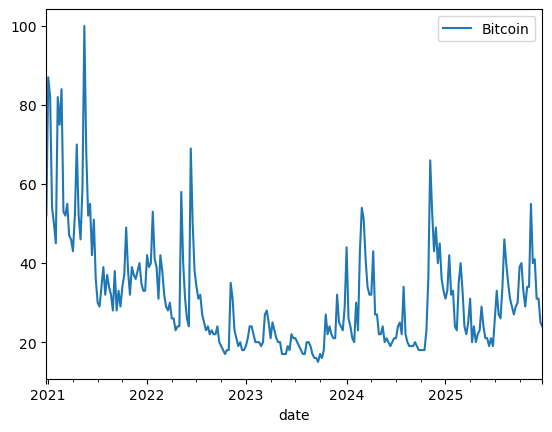

In [59]:
google_sentiment.plot()

In [13]:
import requests
import pandas as pd
from urllib.parse import quote

def wiki_pageviews(page_title: str, start="20210101", end="20260101"):
    page = quote(page_title, safe="")
    url = f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/all-agents/{page}/daily/{start}/{end}"

    headers = {
        "User-Agent": "JuliaHuang-Thesis/1.0 (contact: ydj.huang@mail.utoronto.ca)"
    }

    resp = requests.get(url, headers=headers, timeout=30)
    print("status:", resp.status_code, "content-type:", resp.headers.get("content-type"))

    resp.raise_for_status()
    r = resp.json()

    df = pd.DataFrame({
        "date": [pd.to_datetime(it["timestamp"][:8]) for it in r["items"]],
        "views": [it["views"] for it in r["items"]],
    })
    return df

wikipedia_views = wiki_pageviews("Bitcoin").set_index('date')


status: 200 content-type: application/json; charset=utf-8


Market status (fear and greed)

In [14]:
import requests
import pandas as pd

url = "https://api.alternative.me/fng/?limit=0"  # 0 = all available history
resp = requests.get(url)
resp_data = resp.json()["data"]

market_status = pd.DataFrame(resp_data)

# convert types
market_status["date"] = pd.to_datetime(market_status["timestamp"].astype(int), unit="s")
market_status["fear_greed"] = market_status["value"].astype(int)

# keep just what you need
market_status = market_status[["date", "fear_greed", "value_classification"]]

market_status.sort_values("date", inplace=True)
market_status.reset_index(drop=True, inplace=True)
market_status = market_status.set_index('date')

market_status.head()


,fear_greed,value_classification
date,,
2018-02-01,30,Fear
2018-02-02,15,Extreme Fear
2018-02-03,40,Fear
2018-02-04,24,Extreme Fear
2018-02-05,11,Extreme Fear


Volatility

In [45]:
def get_iv(source, start, end, instr='BTC', resolution=1):
    """
    source = ['block', 'deribit']
    """
    start = datetime.datetime.strptime(start, '%Y%m%d')
    end = datetime.datetime.strptime(end, '%Y%m%d')

    if source == 'block':
        r = requests.get('https://www.theblock.co/api/charts/chart/crypto-markets/options/btc-atm-implied-volatility')
        series_names = r.json()['chart']['jsonFile']['Series'].keys()

        df_vols = []
        for s in series_names:
            df_vol = pd.DataFrame(r.json()['chart']['jsonFile']['Series'][s]['Data'])
            df_vol['duration'] = s
            df_vols.append(df_vol)

        iv_block = pd.concat(df_vols)
        iv_block['Timestamp'] = iv_block['Timestamp'].apply(lambda x: datetime.datetime.fromtimestamp(x))
        iv_block['day'] = iv_block['Timestamp'].apply(lambda x: x.date())
        iv_block = iv_block[(iv_block['day'] >= start.date()) & (iv_block['day'] <= end.date())]
        return iv_block.set_index('Timestamp')
    elif source == 'deribit':
        base_url = "https://www.deribit.com/api/v2/public/get_volatility_index_data"

        if start is None:
            start = datetime.datetime.now(datetime.timezone.utc) - datetime.timedelta(days=7)
        if end is None:
            end = datetime.datetime.now(datetime.timezone.utc)

        # Calculate chunk size based on resolution
        # For hourly data, ~1000 points = ~41 days
        points_per_request = 1000
        seconds_per_chunk = points_per_request * resolution
        chunk_duration = datetime.timedelta(seconds=seconds_per_chunk)

        all_data = []
        current_start = start

        while current_start < end:
            current_end = min(current_start + chunk_duration, end)
            
            start_ts = int(current_start.timestamp() * 1000)
            end_ts = int(current_end.timestamp() * 1000)

            params = {
                "currency": instr.upper(),
                "resolution": resolution,
                "start_timestamp": start_ts,
                "end_timestamp": end_ts,
            }

            r = requests.get(base_url, params=params)
            if r.status_code != 200:
                raise RuntimeError(f"Deribit API error: {r.status_code} {r.text}")

            result = r.json().get("result", {})
            data_values = result.get("data", [])
            
            if data_values:
                all_data.extend(data_values)
                print(f"Fetched {len(data_values)} records for {current_start.date()} to {current_end.date()}. Total: {len(all_data)}")
            
            current_start = current_end

        if not all_data:
            print("⚠️ No data returned. Check your date range or resolution.")
            return pl.DataFrame()

        print(f"Total records fetched: {len(all_data)}")

        # Data format: [timestamp, open, high, low, close]
        df_vol = pl.DataFrame(
            all_data,
            schema=["timestamp", "open", "high", "low", "close"],
            strict=False
        )
        
        # Use close as the IV value
        df_vol = df_vol.select([
            pl.col("timestamp"),
            pl.col("close").alias("iv")
        ])

        # Convert timestamp to datetime (UTC)
        df_vol = df_vol.with_columns(
            pl.col("timestamp").cast(pl.Datetime("ms"))
        )

        df_vol = df_vol.with_columns(
            pl.col("timestamp")
            .dt.replace_time_zone(None)
        )

        # Remove duplicates that might occur at chunk boundaries
        df_vol = df_vol.unique(subset=["timestamp"])

        return df_vol.sort("timestamp").to_pandas()
    
def aggregate_vol(df_vol_klines, period, drop_incomplete=True):

    if period == '1H':
        return df_vol_klines[['Close time', 'realized_vol']].set_index('Close time')
    ann_factor = 1 #np.sqrt(365 * 24)
    agg_vol = df_vol_klines.set_index('Close time').rolling(window=period)["log_return"].std(ddof=0).reset_index().rename(columns={'log_return': 'realized_vol'}).set_index('Close time') * ann_factor
    
    if drop_incomplete:
        agg_vol.loc[:agg_vol.index[0] + pd.Timedelta(period)] = np.nan
        agg_vol = agg_vol.dropna()

    return agg_vol

In [57]:
vol = get_iv('block', '20210101', '20210201')
vol = vol[vol['duration']=='ATM 7']

In [58]:
vol = vol[['day', 'Result']].rename(columns={'day':'date', 'Result': 'vol'}).reset_index(drop=True).set_index('date')

In [59]:
covariates = pd.concat([spread_basis_daily, daily_avg, market_status, vol], axis=1).dropna().drop('value_classification', axis=1)

In [60]:
shocks_formatted = shocks_sp[0.001]['90%'].to_pandas().drop(['Shock', 'event_tick'], axis=1)
shocks_formatted['date'] = pd.to_datetime(shocks_formatted["start_ts"]).dt.date
shocks_formatted = shocks_formatted.merge(covariates.shift(1).reset_index().dropna(), how='inner', on='date')

shocks_formatted[['fundingRate_bps', 'shock_size']] = shocks_formatted[['fundingRate', 'shock_size']] *1e4

In [61]:
shocks_formatted['shock_logt'] = shocks_formatted['shock_size']*np.log(shocks_formatted['Length'])
shocks_formatted['shock_logt_1h'] = (
    shocks_formatted.set_index('start_ts')['shock_logt']
      .shift(1)                       # <-- critical
      .rolling('1H', min_periods=1)
      .mean().reset_index(drop=True)
)
# shocks_formatted['shock_logt_rel'] = shocks_formatted['shock_logt']/shocks_formatted['shock_logt_24h']

In [77]:
shocks_formatted

,start_ts,Status,Length,shock_size,date,spread_spot_avg,spread_perp_avg,basis_avg,fundingRate,fear_greed,fundingRate_bps,shock_logt
0,2021-01-02 08:24:32.246,False,28.220,26.281992,2021-01-02,-0.008034,0.475144,22.982847,0.000304,94.0,3.039650,88.697870
1,2021-01-02 12:20:57.283,True,0.001,0.331994,2021-01-02,-0.008034,0.475144,22.982847,0.000304,94.0,3.039650,0.000332
2,2021-01-02 12:20:57.575,False,2.569,1.001160,2021-01-02,-0.008034,0.475144,22.982847,0.000304,94.0,3.039650,1.273762
3,2021-01-02 12:21:20.771,False,3.042,14.496200,2021-01-02,-0.008034,0.475144,22.982847,0.000304,94.0,3.039650,20.247416
4,2021-01-02 12:21:21.331,True,2.290,21.659997,2021-01-02,-0.008034,0.475144,22.982847,0.000304,94.0,3.039650,25.794621
...,...,...,...,...,...,...,...,...,...,...,...,...
16122,2021-02-01 21:00:50.924,False,35.967,6.037820,2021-02-01,0.021202,0.956704,12.093538,0.000484,78.0,4.843167,21.796685
16123,2021-02-01 22:24:43.623,False,61.994,6.257745,2021-02-01,0.021202,0.956704,12.093538,0.000484,78.0,4.843167,25.926086
16124,2021-02-01 22:38:17.083,False,52.153,0.445893,2021-02-01,0.021202,0.956704,12.093538,0.000484,78.0,4.843167,1.771612
16125,2021-02-01 23:06:03.536,False,44.562,2.668440,2021-02-01,0.021202,0.956704,12.093538,0.000484,78.0,4.843167,10.190970


In [23]:
df = shocks_formatted.drop(['start_ts', 'fundingRate', 'basis_avg', 'fear_greed'], axis=1)
df['Length'] = df['Length'].replace(0,0.001)

In [65]:
shocks_formatted.columns

Index(['start_ts', 'Status', 'Length', 'shock_size', 'date', 'spread_spot_avg',
       'spread_perp_avg', 'basis_avg', 'fundingRate', 'fear_greed',
       'fundingRate_bps', 'shock_logt'],
      dtype='object')

### Cox PH Model

In [63]:
df = shocks_formatted[['Length', 'Status', 'date', 'vol', 'shock_logt_1h', 'fundingRate_bps', 'basis_avg', 'shock_size', 'spread_spot_avg', 'spread_perp_avg']].dropna()
df['Length'] = df['Length'].replace(0,0.001)

In [64]:
from lifelines import CoxPHFitter

df = shocks_formatted[['Length', 'Status', 'date', 'vol', 'shock_logt_1h', 'fundingRate_bps', 'basis_avg']].dropna()
df['Length'] = df['Length'].replace(0,0.001)

# Fit Cox model
cph = CoxPHFitter()
cph.fit(df, duration_col='Length', event_col='Status', cluster_col="date")

# See results
cph.print_summary()

# Coefficients tell you the effect
# β > 0: covariate INCREASES hazard (faster convergence)
# β < 0: covariate DECREASES hazard (slower convergence)

<lifelines.CoxPHFitter: fitted with 16144 total observations, 10489 right-censored observations>
             duration col = 'Length'
                event col = 'Status'
              cluster col = 'date'
          robust variance = True
      baseline estimation = breslow
   number of observations = 16144
number of events observed = 5655
   partial log-likelihood = -52987.99
         time fit was run = 2026-02-07 22:14:00 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
vol              0.00      1.00      0.00            0.00            0.00                1.00                1.00
shock_logt_1h   -0.02      0.98      0.00           -0.02           -0.02                0.98                0.98
fundingRate_bps  0.00      1.00      0.01           -0.02            0.02                0.98                1.02
basis_avg        0.01      1.01      0.00            0.00            0.01                1.00                1.01

                 cmp to     z      p  -log2(p)
covariate                                     
vol                0.00  2.13   0.03      4.90
shock_logt_1h      0.00 -9.30 <0.005     65.99
fundingRate_bps    0.00  0.14   0.89      0.17
basis_avg          0.00  2.19   0.03      5.15
---
Concordance = 0.57
Partial AIC = 105983.99
log-likelihood ratio test = 238.02 on 4 df
-log2(p) of ll-ratio test = 164.79

#### Diagnostics

In [43]:
# Are your variables actually independent?
print(shocks_formatted[['shock_size', 'spread_spot_avg', 'spread_perp_avg', 
          'basis_avg', 'fundingRate_bps']].corr())

# Look for correlations > 0.7 or < -0.7

                 shock_size  spread_spot_avg  spread_perp_avg  basis_avg  \
shock_size         1.000000        -0.010921        -0.152865   0.174638   
spread_spot_avg   -0.010921         1.000000         0.068737  -0.121644   
spread_perp_avg   -0.152865         0.068737         1.000000  -0.554860   
basis_avg          0.174638        -0.121644        -0.554860   1.000000   
fundingRate_bps    0.165331         0.393627        -0.481218   0.583635   

                 fundingRate_bps  
shock_size              0.165331  
spread_spot_avg         0.393627  
spread_perp_avg        -0.481218  
basis_avg               0.583635  
fundingRate_bps         1.000000  


In [30]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF
X = shocks_formatted[['shock_size', 'spread_spot_avg', 'spread_perp_avg', 
        'basis_avg', 'fundingRate_bps', 'fear_greed']]

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))

# If VIF > 10: multicollinearity problem
# Likely culprits: spread_spot vs spread_perp, basis vs fundingRate

          Variable        VIF
5       fear_greed  33.763809
2  spread_perp_avg  19.281632
4  fundingRate_bps   9.046642
3        basis_avg   5.467226
1  spread_spot_avg   3.217127
0       shock_size   1.304721


In [28]:
# What are the actual values?
print(shocks_formatted[['shock_size', 'spread_spot_avg', 'spread_perp_avg', 
          'basis_avg', 'fundingRate_bps']].describe())

# Should see:
# shock_size: If in bps, should be ~10-100 range
# spreads: If in bps, should be ~1-20 range  
# basis: If in bps, should be ~1-10 range
# fundingRate: Already in bps, ~0-5 range

         shock_size  spread_spot_avg  spread_perp_avg     basis_avg  \
count  16375.000000     16375.000000     16375.000000  16375.000000   
mean       4.656118         0.292916         0.883244     12.169781   
std       10.076591         0.301925         0.165560      9.315162   
min        0.000006        -0.008034         0.475144     -0.646129   
25%        0.263464         0.107160         0.753900      3.888714   
50%        1.904549         0.233638         0.912309     10.293819   
75%        5.575649         0.342588         1.004190     18.228583   
max      625.398784         1.329176         1.169372     34.761795   

       fundingRate_bps  
count     16375.000000  
mean          6.081231  
std           4.202072  
min           1.000000  
25%           3.039650  
50%           4.644200  
75%           8.053067  
max          16.215133  


In [26]:
from lifelines.statistics import proportional_hazard_test

# Test the assumption
results = proportional_hazard_test(cph, shocks_formatted.drop(['start_ts', 'fundingRate'], axis=1), time_transform='rank')
print(results)

# Visual check - plot scaled Schoenfeld residuals
# cph.check_assumptions(shocks_formatted.drop(['start_ts', 'fundingRate'], axis=1), p_value_threshold=0.05, show_plots=True)

<lifelines.StatisticalResult: proportional_hazard_test>
    time_transform = rank
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 16375 total observations, 10644 right-censored observations>
         test_name = proportional_hazard_test

---
                 test_statistic    p  -log2(p)
basis_avg                  1.53 0.22      2.21
fear_greed                 0.05 0.82      0.29
fundingRate_bps            2.04 0.15      2.71
shock_size                 0.23 0.63      0.66
spread_perp_avg            0.98 0.32      1.63
spread_spot_avg            0.32 0.57      0.81



   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.6336)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6472)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5687)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5470)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.3231)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3356)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.2165)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2115)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8181)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8279)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1528)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1516)'>]]

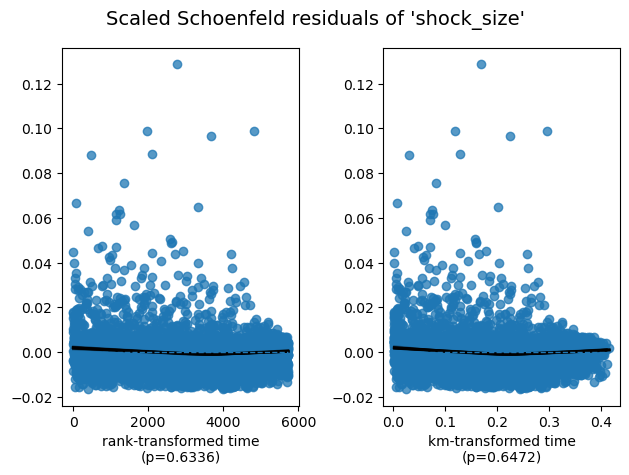

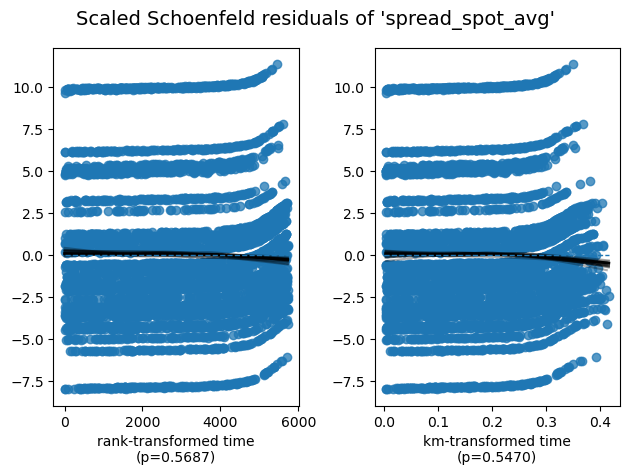

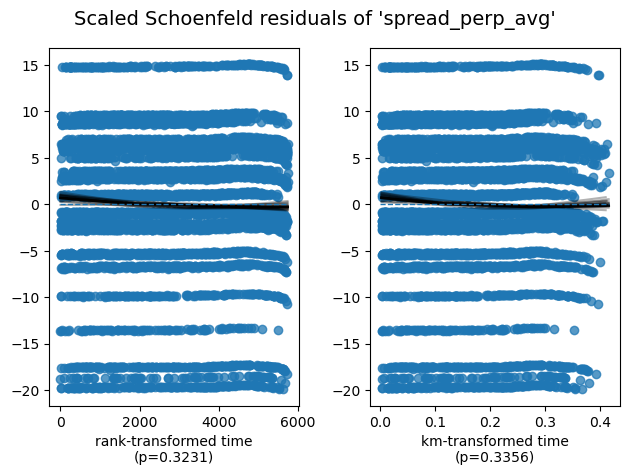

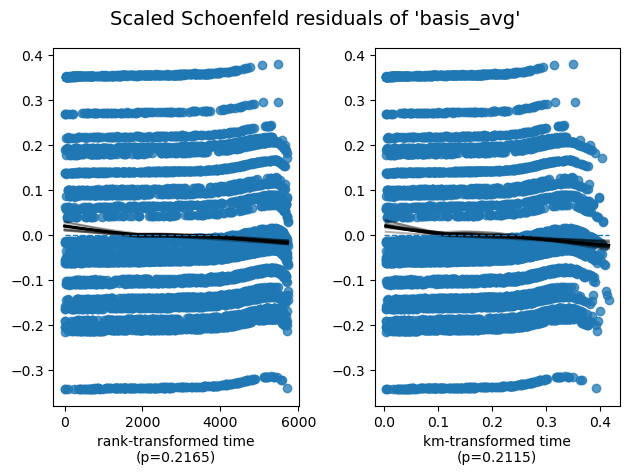

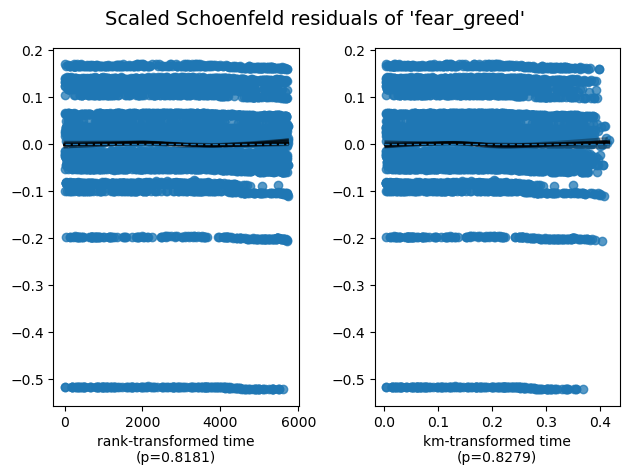

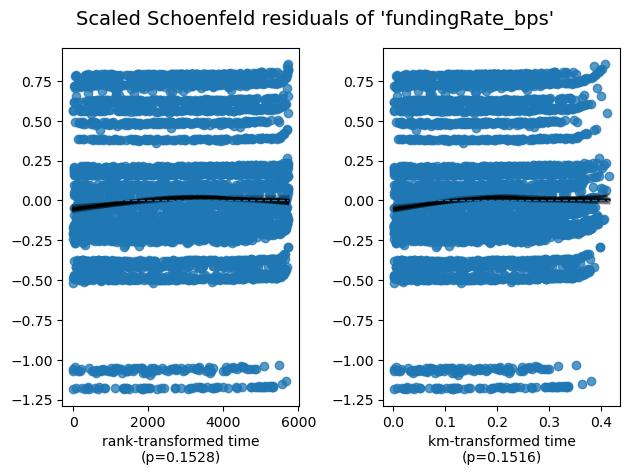

In [33]:
cph.check_assumptions(shocks_formatted.drop(['start_ts', 'fundingRate'], axis=1), show_plots=True)


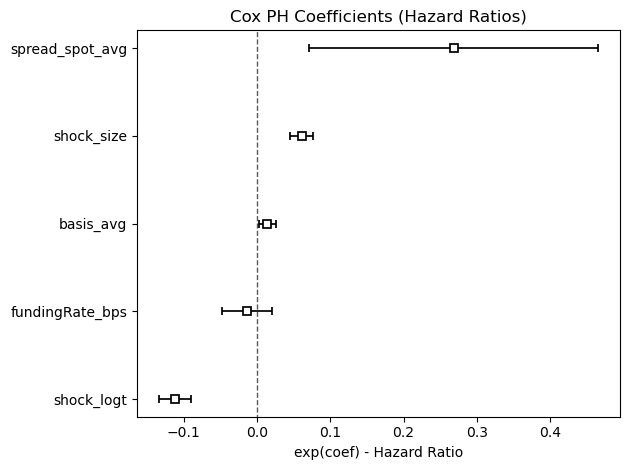

In [76]:
cph.plot()
plt.title('Cox PH Coefficients (Hazard Ratios)')
plt.xlabel('exp(coef) - Hazard Ratio')
plt.tight_layout()
plt.show()

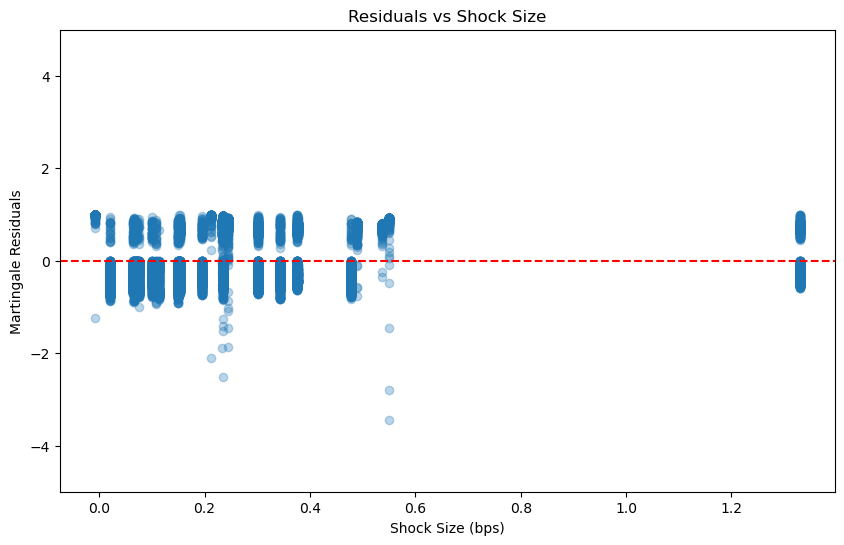

In [64]:
# Martingale residuals (should be randomly scattered around 0)
residuals = cph.compute_residuals(df, kind='martingale')

plt.figure(figsize=(10, 6))
plt.scatter(df['spread_spot_avg'], residuals['martingale'], alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Shock Size (bps)')
plt.ylabel('Martingale Residuals')
plt.title('Residuals vs Shock Size')
plt.ylim(-5,5)
plt.show()

,shock_size,spread_spot_avg,basis_avg,fundingRate_bps,shock_logt
0,1.91139,0.212657,10.977673,4.843167,0.208562


[]

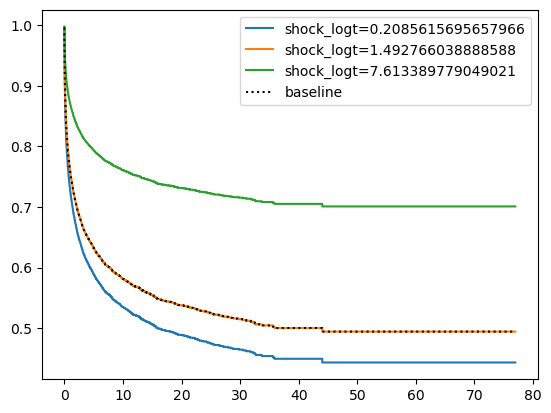

In [109]:

# Define groups (low, medium, high shock)
shock_groups = {
    'Low shock (25th)': df['shock_logt'].quantile(0.25),
    'Medium shock (50th)': df['shock_logt'].quantile(0.50),  
    'High shock (75th)': df['shock_logt'].quantile(0.75)
}

# for label, shock_val in shock_groups.items():
#     # Create scenario with this shock size, other vars at median
#     scenario = df[cph.params_.index].median().to_frame().T
#     scenario['shock_logt'] = shock_val
    
cph.plot_partial_effects_on_outcome(covariates='shock_logt', values=[df['shock_logt'].quantile(0.25),df['shock_logt'].quantile(0.5),df['shock_logt'].quantile(0.75)]).plot(ax=ax, label=label)

ICI =  0.023728855960856176
E50 =  0.024928693561615534


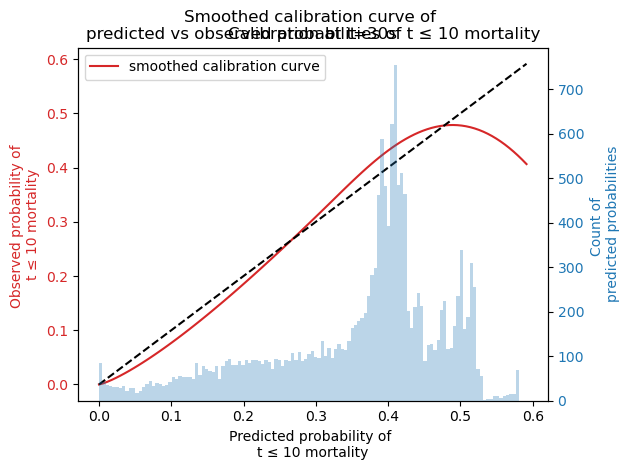

In [76]:
from lifelines.calibration import survival_probability_calibration

# Plot calibration
survival_probability_calibration(cph, df, t0=10)  # At 30 seconds
plt.title('Calibration at t=30s')
plt.show()

ICI =  0.11450647340818991
E50 =  0.08893773317578757


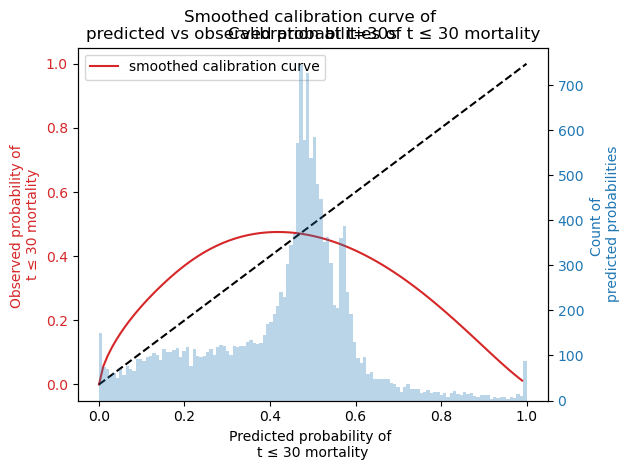

In [ ]:
from lifelines.calibration import survival_probability_calibration

# Plot calibration
survival_probability_calibration(cph, df, t0=10)  # At 30 seconds
plt.title('Calibration at t=30s')
plt.show()

### AFT Model

In [112]:
from lifelines import WeibullAFTFitter

# Fit exponential model
aft = WeibullAFTFitter()
aft.fit(df.drop('date', axis=1), duration_col='Length', event_col='Status')

aft.print_summary(3)  

<lifelines.WeibullAFTFitter: fitted with 16138 total observations, 10482 right-censored observations>
             duration col = 'Length'
                event col = 'Status'
   number of observations = 16138
number of events observed = 5656
           log-likelihood = -15486.220
         time fit was run = 2026-02-03 21:52:31 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                         
lambda_ basis_avg       -0.043     0.958     0.005          -0.053          -0.033               0.948               0.968
        fundingRate_bps  0.032     1.033     0.012           0.008           0.056               1.008               1.058
        shock_logt       0.284     1.328     0.007           0.269           0.298               1.309               1.348
        shock_size      -0.157     0.855     0.002          -0.161          -0.152               0.851               0.859
        spread_spot_avg -0.759     0.468     0.157          -1.067          -0.451               0.344               0.637
        Intercept        4.320    75.183     0.082           4.160           4.480              64.071              88.221
rho_    Intercept       -0.973     0.378     0.012          -0.997          -0.950               0.369               0.387

                         cmp to       z       p  -log2(p)
param   covariate                                        
lambda_ basis_avg         0.000  -8.174 <0.0005    51.576
        fundingRate_bps   0.000   2.588   0.010     6.693
        shock_logt        0.000  38.221 <0.0005       inf
        shock_size        0.000 -69.641 <0.0005       inf
        spread_spot_avg   0.000  -4.831 <0.0005    19.488
        Intercept         0.000  52.942 <0.0005       inf
rho_    Intercept         0.000 -82.436 <0.0005       inf
---
Concordance = 0.779
AIC = 30986.440
log-likelihood ratio test = 3613.390 on 5 df
-log2(p) of ll-ratio test = inf

<Axes: xlabel='log(accelerated failure rate) (95% CI)'>

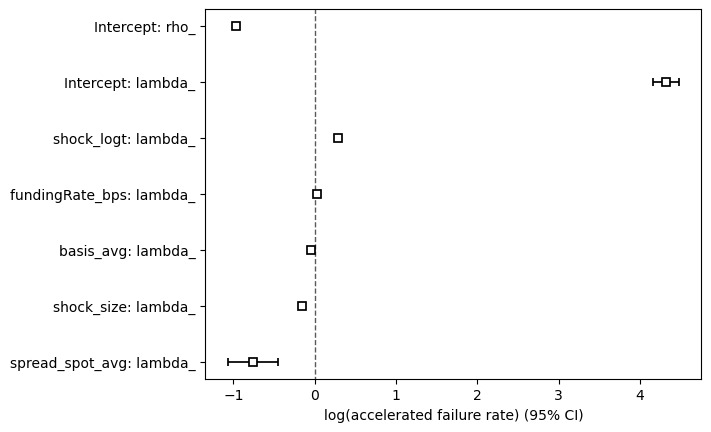

In [113]:
aft.plot()

Text(0.5, 1.0, 'Not modelling rho_')

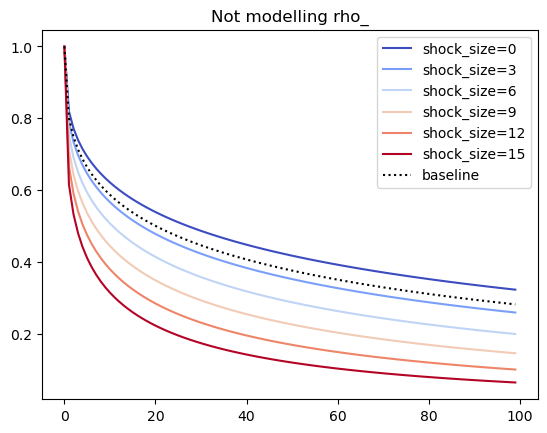

In [118]:
times = np.arange(0, 100)
wft_not_model_rho = WeibullAFTFitter().fit(df.drop('date', axis=1), duration_col='Length', event_col='Status', ancillary=False, timeline=times)
wft_not_model_rho.plot_partial_effects_on_outcome('shock_size', range(0, 16, 3), cmap='coolwarm')
plt.title("Not modelling rho_")

suspiciously good fit... drop?

In [122]:
from lifelines import LogNormalAFTFitter

aft_ln = LogNormalAFTFitter()
aft_ln.fit(df, "Length", "Status", formula="shock_size + shock_logt + spread_spot_avg + basis_avg + fundingRate_bps")
aft_ln.print_summary(3)

<lifelines.LogNormalAFTFitter: fitted with 16138 total observations, 10482 right-censored observations>
             duration col = 'Length'
                event col = 'Status'
   number of observations = 16138
number of events observed = 5656
           log-likelihood = -14435.310
         time fit was run = 2026-02-03 22:03:23 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                         
mu_    Intercept        3.222    25.081     0.078           3.070           3.374              21.545              29.198
       shock_size      -0.310     0.733     0.005          -0.320          -0.300               0.726               0.741
       shock_logt       0.361     1.435     0.006           0.349           0.374               1.417               1.454
       spread_spot_avg -0.512     0.599     0.151          -0.808          -0.217               0.446               0.805
       basis_avg       -0.014     0.986     0.005          -0.024          -0.004               0.976               0.996
       fundingRate_bps  0.019     1.019     0.012          -0.005           0.042               0.995               1.043
sigma_ Intercept        1.253     3.499     0.011           1.232           1.273               3.428               3.573

                        cmp to       z       p  -log2(p)
param  covariate                                        
mu_    Intercept         0.000  41.555 <0.0005       inf
       shock_size        0.000 -59.902 <0.0005       inf
       shock_logt        0.000  55.775 <0.0005       inf
       spread_spot_avg   0.000  -3.397   0.001    10.518
       basis_avg         0.000  -2.794   0.005     7.586
       fundingRate_bps   0.000   1.574   0.115     3.115
sigma_ Intercept         0.000 118.654 <0.0005       inf
---
Concordance = 0.841
AIC = 28884.620
log-likelihood ratio test = 4988.750 on 5 df
-log2(p) of ll-ratio test = inf

Text(0.5, 1.0, 'Not modelling rho_')

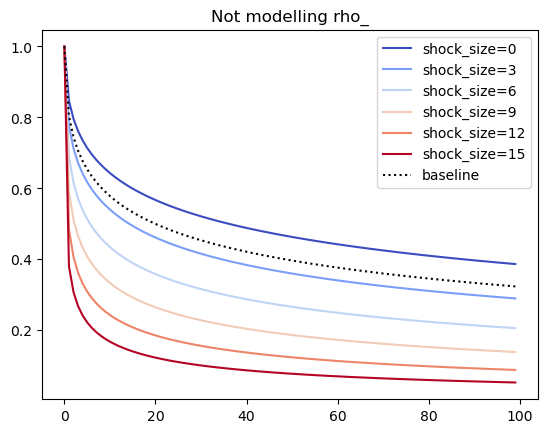

In [123]:
times = np.arange(0, 100)
wft_not_model_rho = LogNormalAFTFitter().fit(df.drop('date', axis=1), duration_col='Length', event_col='Status', ancillary=False, timeline=times)
wft_not_model_rho.plot_partial_effects_on_outcome('shock_size', range(0, 16, 3), cmap='coolwarm')
plt.title("Not modelling rho_")

Want to collect all the shocks, then fit different subsets of the data to different models

In [66]:
import datetime
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time
from trade_data_pull import *
from survival_analysis import *

In [67]:
start = '20210101'
end = '20220101'

In [68]:
start_dt = datetime.datetime.strptime(start, '%Y%m%d')
end_dt = datetime.datetime.strptime(end, '%Y%m%d')

In [69]:
sa = SurvivalAnalysis('BTCUSDT')

In [70]:
curr_start_dt = end_dt - datetime.timedelta(days=30)
curr_end_dt = end_dt
collection = {}
save_csv=True 
while curr_start_dt >= start_dt:
    print(curr_start_dt)
    data_i, events_i, shocks_i = sa.fit_KM(datetime.datetime.strftime(curr_start_dt, '%Y%m%d'), datetime.datetime.strftime(curr_end_dt, '%Y%m%d'), [0.001])
    if save_csv:
        # events_i[0.001].to_csv(f'sa_results/events_{datetime.datetime.strftime(curr_start_dt, '%Y%m%d')}_{datetime.datetime.strftime(curr_end_dt, '%Y%m%d')}.csv')
        collection[curr_start_dt] = [data_i, events_i[0.001], shocks_i[0.001]['90%'].to_pandas()]
    
    curr_end_dt = curr_end_dt - datetime.timedelta(days=30)
    curr_start_dt = curr_end_dt - datetime.timedelta(days=30)

2021-12-02 00:00:00
Fetching file list from Binance...
Processing 31 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
Using cached file list...
Processing 31 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
2021-11-02 00:00:00
Fetching file list from Binance...
Processing 31 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
Using cached file list...
Processing 31 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
2021-10-03 00:00:00
Fetching file list from Binance...
Processing 31 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
Using cached file list...
Processing 31 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
2021-09-03 00:00:00
Fetching file list from Binance...
Processing 31 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
Using cached file list...
Processing 31 files...
Processing batch 1/2
Processing batch 2/2
Combining

: 

In [ ]:
sa = SurvivalAnalysis('BTCUSDT')

data, events_sp, shocks_sp = sa.fit_KM('20210101', '20210201', [0.001])

## ETH

#### Kaplan-Meier Plots

In [ ]:
# spot POV (spot to perps)
sa = SurvivalAnalysis('ETHUSDT', 'Binance', 'um')
data_sp, events_sp, shocks_sp = sa.fit_KM('20251201', '20251231', [0.001])

Processing 30 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
Processing 30 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
lee_mykland 3.0 0.99 None 0.0010000000000000009 True spot


In [ ]:
# perp POV (perps to spot)
data_ps, events_ps, shocks_ps = sa.fit_KM('20251201', '20251231', [0.001], first='perp')

Processing 30 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
Processing 30 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
lee_mykland 3.0 0.99 None 0.0010000000000000009 True perp


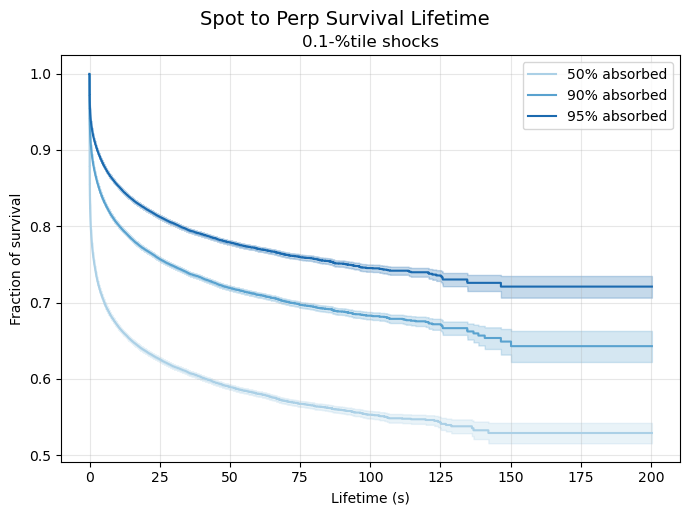

In [ ]:
kmfs = sa.graph_results(shocks_sp, [0.001], ncols=1, figsize=(7,5), first='spot')

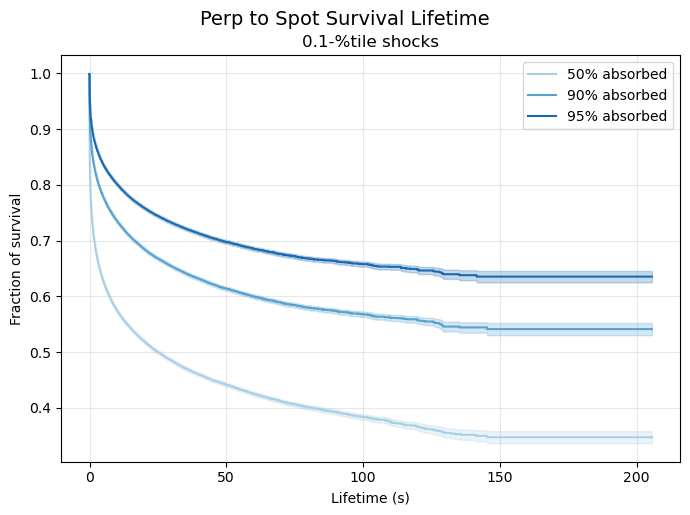

In [ ]:
kmfs = sa.graph_results(shocks_ps, [0.001], ncols=1, figsize=(7,5), first='perp')

In [ ]:
# sa = SurvivalAnalysis('BTCUSDT')
# # df_ret_joined contains funding rates
# data, df_ret_joined = sa._get_and_parse_data('20210101', '20210201')

Fetching file list from Binance...
Processing 32 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
Using cached file list...
Processing 32 files...
Processing batch 1/2
Processing batch 2/2
Combining results...


#### Grabbing Covariates

Finding spread and basis

In [ ]:
spots_bidask = data.to_intervals_bidask(data.df_trades_spots, '1s').to_pandas().set_index('timestamp_bin')
spots_bidask['spread_spot'] = spots_bidask['ask_price'] - spots_bidask['bid_price']

perps_bidask = data.to_intervals_bidask(data.df_trades_perps, '1s').to_pandas().set_index('timestamp_bin')
perps_bidask['spread_perp'] = perps_bidask['ask_price'] - perps_bidask['bid_price']

In [ ]:
bidask = spots_bidask.merge(perps_bidask, how='inner', left_index=True, right_index=True, suffixes=['_spot', '_perp']).dropna()
bidask['midpoint_spot'] = (bidask['ask_price_spot'] + bidask['bid_price_spot'])/2
bidask['midpoint_perp'] = (bidask['ask_price_perp'] + bidask['bid_price_perp'])/2
bidask['basis'] = bidask['midpoint_perp'] - bidask['midpoint_spot']
bidask['spread_spot'] = bidask['spread_spot']/bidask['midpoint_spot']*10000
bidask['spread_perp'] = bidask['spread_perp']/bidask['midpoint_perp']*10000
bidask['basis'] = bidask['basis']/bidask['midpoint_spot']*10000
bidask = bidask.reset_index()

In [ ]:
# aggregated by day
bidask["date"] = pd.to_datetime(bidask['timestamp_bin']).dt.date

bidask =  bidask.merge(
    bidask
    .groupby("date")[["spread_spot", 'spread_perp', 'basis']]
    .mean().reset_index().rename(columns={'spread_spot':'spread_spot_avg','spread_perp':'spread_perp_avg', 'basis':'basis_avg'}), how='outer', on='date'
)

In [ ]:
spread_basis_daily = bidask[['date', 'spread_spot_avg', 'spread_perp_avg', 'basis_avg']].drop_duplicates().set_index('date')

Trade volume

In [ ]:
data.convert_tz = None

In [ ]:
spot_volume = data.get_klines('20210101', '20210201', 'spot', '1d', columns=["Open time", "Close time", 'Open', "Close", "log_return", 'Volume'])
perp_volume = data.get_klines('20210101', '20210201', 'perp', '1d', columns=["Open time", "Close time", 'Open', "Close", "log_return", 'Volume'])

In [ ]:
spot_volume_daily = spot_volume.rename(columns={'Open time':'date','Volume':'volume'})[['date','volume']].set_index('date')

Funding fees (8H)

In [ ]:
funding = data.get_funding_data('20210101', '20210201')

In [ ]:
funding["date"] = pd.to_datetime(funding["fundingTime"]).dt.date

daily_avg = (
    funding
    .groupby("date")["fundingRate"]
    .mean()
)

Google search index

In [ ]:
from pytrends.request import TrendReq
import pandas as pd

pytrends = TrendReq(hl='en-US', tz=0)

pytrends.build_payload(
    kw_list=["Bitcoin"],
    timeframe="2021-01-01 2026-01-01",
    geo=""
)

data = pytrends.interest_over_time()
google_sentiment = data[["Bitcoin"]]


<Axes: xlabel='date'>

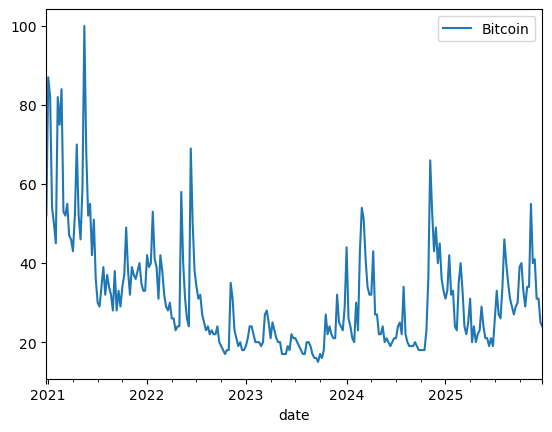

In [ ]:
google_sentiment.plot()

In [ ]:
import requests
import pandas as pd
from urllib.parse import quote

def wiki_pageviews(page_title: str, start="20210101", end="20260101"):
    page = quote(page_title, safe="")
    url = f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/all-agents/{page}/daily/{start}/{end}"

    headers = {
        "User-Agent": "JuliaHuang-Thesis/1.0 (contact: ydj.huang@mail.utoronto.ca)"
    }

    resp = requests.get(url, headers=headers, timeout=30)
    print("status:", resp.status_code, "content-type:", resp.headers.get("content-type"))

    resp.raise_for_status()
    r = resp.json()

    df = pd.DataFrame({
        "date": [pd.to_datetime(it["timestamp"][:8]) for it in r["items"]],
        "views": [it["views"] for it in r["items"]],
    })
    return df

wikipedia_views = wiki_pageviews("Bitcoin").set_index('date')


status: 200 content-type: application/json; charset=utf-8


Market status (fear and greed)

In [ ]:
import requests
import pandas as pd

url = "https://api.alternative.me/fng/?limit=0"  # 0 = all available history
resp = requests.get(url)
resp_data = resp.json()["data"]

market_status = pd.DataFrame(resp_data)

# convert types
market_status["date"] = pd.to_datetime(market_status["timestamp"].astype(int), unit="s")
market_status["fear_greed"] = market_status["value"].astype(int)

# keep just what you need
market_status = market_status[["date", "fear_greed", "value_classification"]]

market_status.sort_values("date", inplace=True)
market_status.reset_index(drop=True, inplace=True)
market_status = market_status.set_index('date')

market_status.head()


,fear_greed,value_classification
date,,
2018-02-01,30,Fear
2018-02-02,15,Extreme Fear
2018-02-03,40,Fear
2018-02-04,24,Extreme Fear
2018-02-05,11,Extreme Fear


Volatility

In [ ]:
def get_iv(source, start, end, instr='BTC', resolution=1):
    """
    source = ['block', 'deribit']
    """
    start = datetime.datetime.strptime(start, '%Y%m%d')
    end = datetime.datetime.strptime(end, '%Y%m%d')

    if source == 'block':
        r = requests.get('https://www.theblock.co/api/charts/chart/crypto-markets/options/btc-atm-implied-volatility')
        series_names = r.json()['chart']['jsonFile']['Series'].keys()

        df_vols = []
        for s in series_names:
            df_vol = pd.DataFrame(r.json()['chart']['jsonFile']['Series'][s]['Data'])
            df_vol['duration'] = s
            df_vols.append(df_vol)

        iv_block = pd.concat(df_vols)
        iv_block['Timestamp'] = iv_block['Timestamp'].apply(lambda x: datetime.datetime.fromtimestamp(x))
        iv_block['day'] = iv_block['Timestamp'].apply(lambda x: x.date())
        iv_block = iv_block[(iv_block['day'] >= start.date()) & (iv_block['day'] <= end.date())]
        return iv_block.set_index('Timestamp')
    elif source == 'deribit':
        base_url = "https://www.deribit.com/api/v2/public/get_volatility_index_data"

        if start is None:
            start = datetime.datetime.now(datetime.timezone.utc) - datetime.timedelta(days=7)
        if end is None:
            end = datetime.datetime.now(datetime.timezone.utc)

        # Calculate chunk size based on resolution
        # For hourly data, ~1000 points = ~41 days
        points_per_request = 1000
        seconds_per_chunk = points_per_request * resolution
        chunk_duration = datetime.timedelta(seconds=seconds_per_chunk)

        all_data = []
        current_start = start

        while current_start < end:
            current_end = min(current_start + chunk_duration, end)
            
            start_ts = int(current_start.timestamp() * 1000)
            end_ts = int(current_end.timestamp() * 1000)

            params = {
                "currency": instr.upper(),
                "resolution": resolution,
                "start_timestamp": start_ts,
                "end_timestamp": end_ts,
            }

            r = requests.get(base_url, params=params)
            if r.status_code != 200:
                raise RuntimeError(f"Deribit API error: {r.status_code} {r.text}")

            result = r.json().get("result", {})
            data_values = result.get("data", [])
            
            if data_values:
                all_data.extend(data_values)
                print(f"Fetched {len(data_values)} records for {current_start.date()} to {current_end.date()}. Total: {len(all_data)}")
            
            current_start = current_end

        if not all_data:
            print("⚠️ No data returned. Check your date range or resolution.")
            return pl.DataFrame()

        print(f"Total records fetched: {len(all_data)}")

        # Data format: [timestamp, open, high, low, close]
        df_vol = pl.DataFrame(
            all_data,
            schema=["timestamp", "open", "high", "low", "close"],
            strict=False
        )
        
        # Use close as the IV value
        df_vol = df_vol.select([
            pl.col("timestamp"),
            pl.col("close").alias("iv")
        ])

        # Convert timestamp to datetime (UTC)
        df_vol = df_vol.with_columns(
            pl.col("timestamp").cast(pl.Datetime("ms"))
        )

        df_vol = df_vol.with_columns(
            pl.col("timestamp")
            .dt.replace_time_zone(None)
        )

        # Remove duplicates that might occur at chunk boundaries
        df_vol = df_vol.unique(subset=["timestamp"])

        return df_vol.sort("timestamp").to_pandas()
    
def aggregate_vol(df_vol_klines, period, drop_incomplete=True):

    if period == '1H':
        return df_vol_klines[['Close time', 'realized_vol']].set_index('Close time')
    ann_factor = 1 #np.sqrt(365 * 24)
    agg_vol = df_vol_klines.set_index('Close time').rolling(window=period)["log_return"].std(ddof=0).reset_index().rename(columns={'log_return': 'realized_vol'}).set_index('Close time') * ann_factor
    
    if drop_incomplete:
        agg_vol.loc[:agg_vol.index[0] + pd.Timedelta(period)] = np.nan
        agg_vol = agg_vol.dropna()

    return agg_vol

In [ ]:
vol = get_iv('block', '20210101', '20210201')
vol = vol[vol['duration']=='ATM 7']

In [ ]:
vol = vol[['day', 'Result']].rename(columns={'day':'date', 'Result': 'vol'}).reset_index(drop=True).set_index('date')

In [ ]:
covariates = pd.concat([spread_basis_daily, daily_avg, market_status, vol], axis=1).dropna().drop('value_classification', axis=1)

In [ ]:
shocks_formatted = shocks_sp[0.001]['90%'].to_pandas().drop(['Shock', 'event_tick'], axis=1)
shocks_formatted['date'] = pd.to_datetime(shocks_formatted["start_ts"]).dt.date
shocks_formatted = shocks_formatted.merge(covariates.shift(1).reset_index().dropna(), how='inner', on='date')

shocks_formatted[['fundingRate_bps', 'shock_size']] = shocks_formatted[['fundingRate', 'shock_size']] *1e4

In [ ]:
shocks_formatted['shock_logt'] = shocks_formatted['shock_size']*np.log(shocks_formatted['Length'])
shocks_formatted['shock_logt_1h'] = (
    shocks_formatted.set_index('start_ts')['shock_logt']
      .shift(1)                       # <-- critical
      .rolling('1H', min_periods=1)
      .mean().reset_index(drop=True)
)
# shocks_formatted['shock_logt_rel'] = shocks_formatted['shock_logt']/shocks_formatted['shock_logt_24h']

In [ ]:
shocks_formatted

,start_ts,Status,Length,shock_size,date,spread_spot_avg,spread_perp_avg,basis_avg,fundingRate,fear_greed,fundingRate_bps,shock_logt
0,2021-01-02 08:24:32.246,False,28.220,26.281992,2021-01-02,-0.008034,0.475144,22.982847,0.000304,94.0,3.039650,88.697870
1,2021-01-02 12:20:57.283,True,0.001,0.331994,2021-01-02,-0.008034,0.475144,22.982847,0.000304,94.0,3.039650,0.000332
2,2021-01-02 12:20:57.575,False,2.569,1.001160,2021-01-02,-0.008034,0.475144,22.982847,0.000304,94.0,3.039650,1.273762
3,2021-01-02 12:21:20.771,False,3.042,14.496200,2021-01-02,-0.008034,0.475144,22.982847,0.000304,94.0,3.039650,20.247416
4,2021-01-02 12:21:21.331,True,2.290,21.659997,2021-01-02,-0.008034,0.475144,22.982847,0.000304,94.0,3.039650,25.794621
...,...,...,...,...,...,...,...,...,...,...,...,...
16122,2021-02-01 21:00:50.924,False,35.967,6.037820,2021-02-01,0.021202,0.956704,12.093538,0.000484,78.0,4.843167,21.796685
16123,2021-02-01 22:24:43.623,False,61.994,6.257745,2021-02-01,0.021202,0.956704,12.093538,0.000484,78.0,4.843167,25.926086
16124,2021-02-01 22:38:17.083,False,52.153,0.445893,2021-02-01,0.021202,0.956704,12.093538,0.000484,78.0,4.843167,1.771612
16125,2021-02-01 23:06:03.536,False,44.562,2.668440,2021-02-01,0.021202,0.956704,12.093538,0.000484,78.0,4.843167,10.190970


In [ ]:
df = shocks_formatted.drop(['start_ts', 'fundingRate', 'basis_avg', 'fear_greed'], axis=1)
df['Length'] = df['Length'].replace(0,0.001)

In [ ]:
shocks_formatted.columns

Index(['start_ts', 'Status', 'Length', 'shock_size', 'date', 'spread_spot_avg',
       'spread_perp_avg', 'basis_avg', 'fundingRate', 'fear_greed',
       'fundingRate_bps', 'shock_logt'],
      dtype='object')

### Cox PH Model

In [ ]:
df = shocks_formatted[['Length', 'Status', 'date', 'vol', 'shock_logt_1h', 'fundingRate_bps', 'basis_avg', 'shock_size', 'spread_spot_avg', 'spread_perp_avg']].dropna()
df['Length'] = df['Length'].replace(0,0.001)

In [ ]:
from lifelines import CoxPHFitter

df = shocks_formatted[['Length', 'Status', 'date', 'vol', 'shock_logt_1h', 'fundingRate_bps', 'basis_avg']].dropna()
df['Length'] = df['Length'].replace(0,0.001)

# Fit Cox model
cph = CoxPHFitter()
cph.fit(df, duration_col='Length', event_col='Status', cluster_col="date")

# See results
cph.print_summary()

# Coefficients tell you the effect
# β > 0: covariate INCREASES hazard (faster convergence)
# β < 0: covariate DECREASES hazard (slower convergence)

<lifelines.CoxPHFitter: fitted with 16144 total observations, 10489 right-censored observations>
             duration col = 'Length'
                event col = 'Status'
              cluster col = 'date'
          robust variance = True
      baseline estimation = breslow
   number of observations = 16144
number of events observed = 5655
   partial log-likelihood = -52987.99
         time fit was run = 2026-02-07 22:14:00 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
vol              0.00      1.00      0.00            0.00            0.00                1.00                1.00
shock_logt_1h   -0.02      0.98      0.00           -0.02           -0.02                0.98                0.98
fundingRate_bps  0.00      1.00      0.01           -0.02            0.02                0.98                1.02
basis_avg        0.01      1.01      0.00            0.00            0.01                1.00                1.01

                 cmp to     z      p  -log2(p)
covariate                                     
vol                0.00  2.13   0.03      4.90
shock_logt_1h      0.00 -9.30 <0.005     65.99
fundingRate_bps    0.00  0.14   0.89      0.17
basis_avg          0.00  2.19   0.03      5.15
---
Concordance = 0.57
Partial AIC = 105983.99
log-likelihood ratio test = 238.02 on 4 df
-log2(p) of ll-ratio test = 164.79

#### Diagnostics

In [ ]:
# Are your variables actually independent?
print(shocks_formatted[['shock_size', 'spread_spot_avg', 'spread_perp_avg', 
          'basis_avg', 'fundingRate_bps']].corr())

# Look for correlations > 0.7 or < -0.7

                 shock_size  spread_spot_avg  spread_perp_avg  basis_avg  \
shock_size         1.000000        -0.010921        -0.152865   0.174638   
spread_spot_avg   -0.010921         1.000000         0.068737  -0.121644   
spread_perp_avg   -0.152865         0.068737         1.000000  -0.554860   
basis_avg          0.174638        -0.121644        -0.554860   1.000000   
fundingRate_bps    0.165331         0.393627        -0.481218   0.583635   

                 fundingRate_bps  
shock_size              0.165331  
spread_spot_avg         0.393627  
spread_perp_avg        -0.481218  
basis_avg               0.583635  
fundingRate_bps         1.000000  


In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF
X = shocks_formatted[['shock_size', 'spread_spot_avg', 'spread_perp_avg', 
        'basis_avg', 'fundingRate_bps', 'fear_greed']]

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))

# If VIF > 10: multicollinearity problem
# Likely culprits: spread_spot vs spread_perp, basis vs fundingRate

          Variable        VIF
5       fear_greed  33.763809
2  spread_perp_avg  19.281632
4  fundingRate_bps   9.046642
3        basis_avg   5.467226
1  spread_spot_avg   3.217127
0       shock_size   1.304721


In [ ]:
# What are the actual values?
print(shocks_formatted[['shock_size', 'spread_spot_avg', 'spread_perp_avg', 
          'basis_avg', 'fundingRate_bps']].describe())

# Should see:
# shock_size: If in bps, should be ~10-100 range
# spreads: If in bps, should be ~1-20 range  
# basis: If in bps, should be ~1-10 range
# fundingRate: Already in bps, ~0-5 range

         shock_size  spread_spot_avg  spread_perp_avg     basis_avg  \
count  16375.000000     16375.000000     16375.000000  16375.000000   
mean       4.656118         0.292916         0.883244     12.169781   
std       10.076591         0.301925         0.165560      9.315162   
min        0.000006        -0.008034         0.475144     -0.646129   
25%        0.263464         0.107160         0.753900      3.888714   
50%        1.904549         0.233638         0.912309     10.293819   
75%        5.575649         0.342588         1.004190     18.228583   
max      625.398784         1.329176         1.169372     34.761795   

       fundingRate_bps  
count     16375.000000  
mean          6.081231  
std           4.202072  
min           1.000000  
25%           3.039650  
50%           4.644200  
75%           8.053067  
max          16.215133  


In [ ]:
from lifelines.statistics import proportional_hazard_test

# Test the assumption
results = proportional_hazard_test(cph, shocks_formatted.drop(['start_ts', 'fundingRate'], axis=1), time_transform='rank')
print(results)

# Visual check - plot scaled Schoenfeld residuals
# cph.check_assumptions(shocks_formatted.drop(['start_ts', 'fundingRate'], axis=1), p_value_threshold=0.05, show_plots=True)

<lifelines.StatisticalResult: proportional_hazard_test>
    time_transform = rank
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 16375 total observations, 10644 right-censored observations>
         test_name = proportional_hazard_test

---
                 test_statistic    p  -log2(p)
basis_avg                  1.53 0.22      2.21
fear_greed                 0.05 0.82      0.29
fundingRate_bps            2.04 0.15      2.71
shock_size                 0.23 0.63      0.66
spread_perp_avg            0.98 0.32      1.63
spread_spot_avg            0.32 0.57      0.81



   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.6336)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6472)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5687)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5470)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.3231)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3356)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.2165)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2115)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8181)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8279)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1528)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1516)'>]]

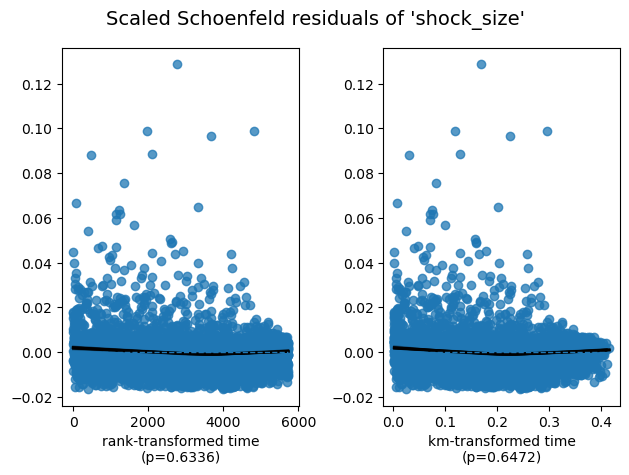

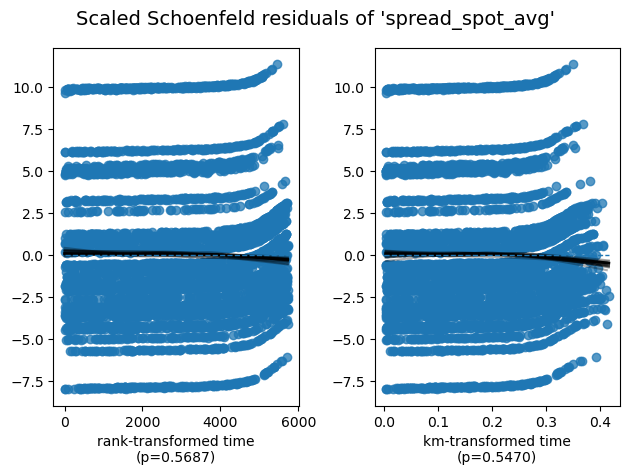

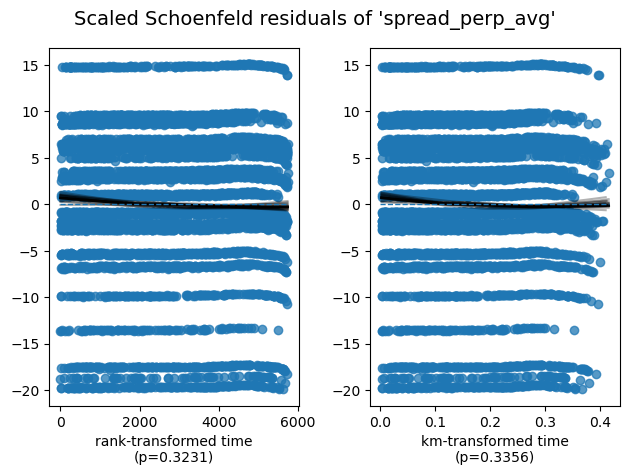

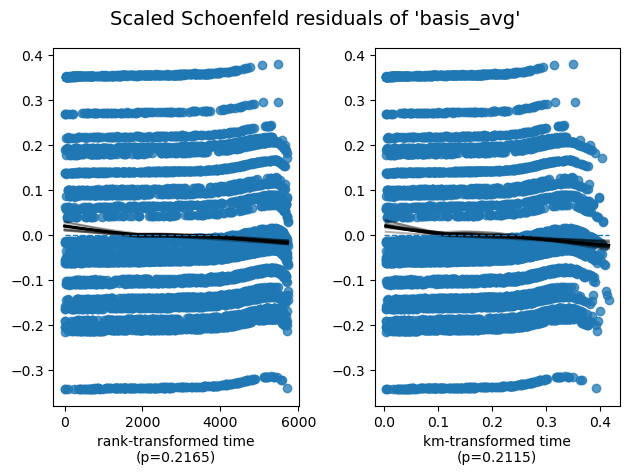

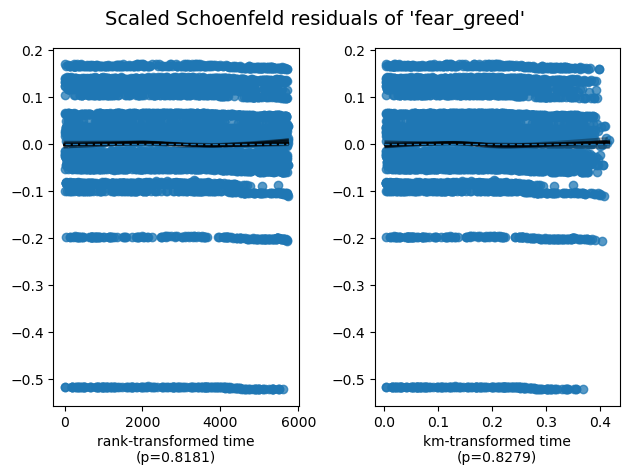

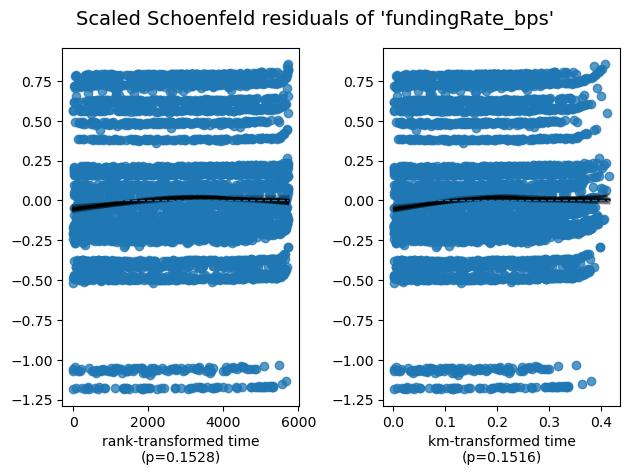

In [ ]:
cph.check_assumptions(shocks_formatted.drop(['start_ts', 'fundingRate'], axis=1), show_plots=True)


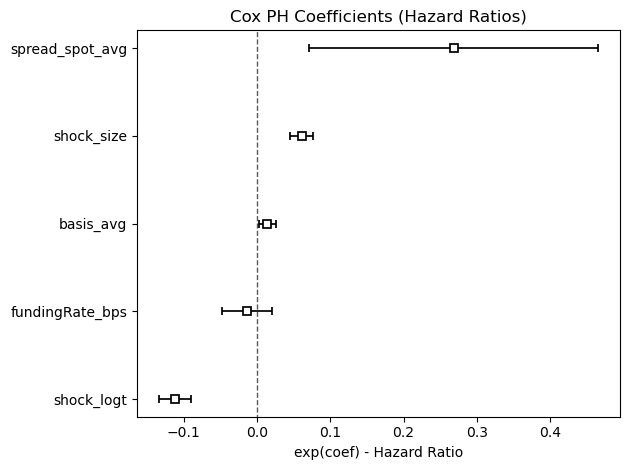

In [ ]:
cph.plot()
plt.title('Cox PH Coefficients (Hazard Ratios)')
plt.xlabel('exp(coef) - Hazard Ratio')
plt.tight_layout()
plt.show()

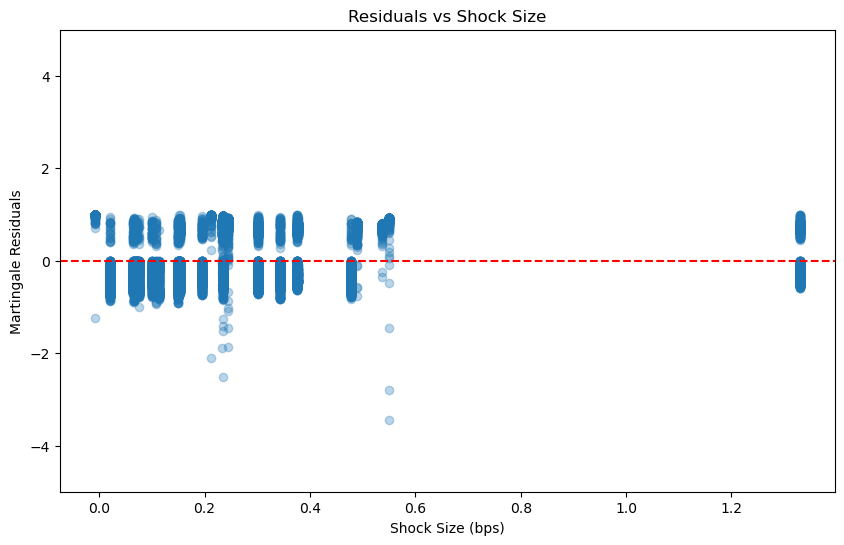

In [ ]:
# Martingale residuals (should be randomly scattered around 0)
residuals = cph.compute_residuals(df, kind='martingale')

plt.figure(figsize=(10, 6))
plt.scatter(df['spread_spot_avg'], residuals['martingale'], alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Shock Size (bps)')
plt.ylabel('Martingale Residuals')
plt.title('Residuals vs Shock Size')
plt.ylim(-5,5)
plt.show()

,shock_size,spread_spot_avg,basis_avg,fundingRate_bps,shock_logt
0,1.91139,0.212657,10.977673,4.843167,0.208562


[]

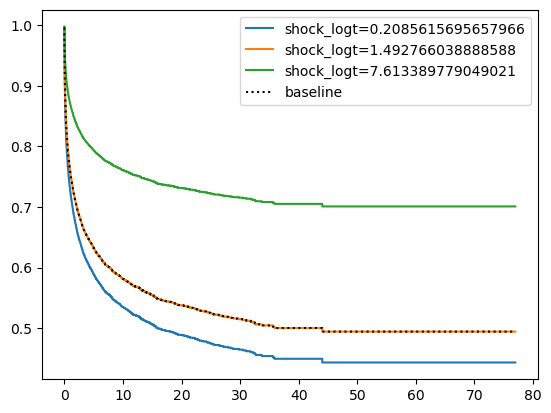

In [ ]:

# Define groups (low, medium, high shock)
shock_groups = {
    'Low shock (25th)': df['shock_logt'].quantile(0.25),
    'Medium shock (50th)': df['shock_logt'].quantile(0.50),  
    'High shock (75th)': df['shock_logt'].quantile(0.75)
}

# for label, shock_val in shock_groups.items():
#     # Create scenario with this shock size, other vars at median
#     scenario = df[cph.params_.index].median().to_frame().T
#     scenario['shock_logt'] = shock_val
    
cph.plot_partial_effects_on_outcome(covariates='shock_logt', values=[df['shock_logt'].quantile(0.25),df['shock_logt'].quantile(0.5),df['shock_logt'].quantile(0.75)]).plot(ax=ax, label=label)

ICI =  0.023728855960856176
E50 =  0.024928693561615534


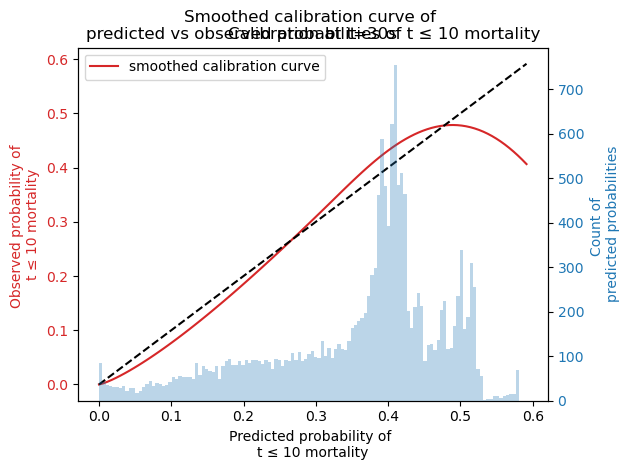

In [ ]:
from lifelines.calibration import survival_probability_calibration

# Plot calibration
survival_probability_calibration(cph, df, t0=10)  # At 30 seconds
plt.title('Calibration at t=30s')
plt.show()

ICI =  0.11450647340818991
E50 =  0.08893773317578757


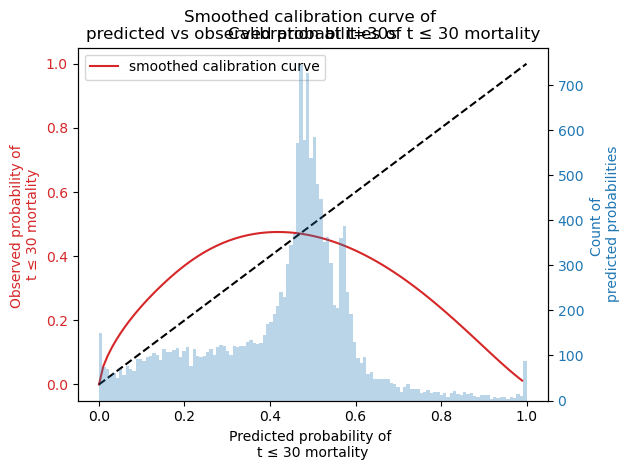

In [ ]:
from lifelines.calibration import survival_probability_calibration

# Plot calibration
survival_probability_calibration(cph, df, t0=10)  # At 30 seconds
plt.title('Calibration at t=30s')
plt.show()

### AFT Model

In [ ]:
from lifelines import WeibullAFTFitter

# Fit exponential model
aft = WeibullAFTFitter()
aft.fit(df.drop('date', axis=1), duration_col='Length', event_col='Status')

aft.print_summary(3)  

<lifelines.WeibullAFTFitter: fitted with 16138 total observations, 10482 right-censored observations>
             duration col = 'Length'
                event col = 'Status'
   number of observations = 16138
number of events observed = 5656
           log-likelihood = -15486.220
         time fit was run = 2026-02-03 21:52:31 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                         
lambda_ basis_avg       -0.043     0.958     0.005          -0.053          -0.033               0.948               0.968
        fundingRate_bps  0.032     1.033     0.012           0.008           0.056               1.008               1.058
        shock_logt       0.284     1.328     0.007           0.269           0.298               1.309               1.348
        shock_size      -0.157     0.855     0.002          -0.161          -0.152               0.851               0.859
        spread_spot_avg -0.759     0.468     0.157          -1.067          -0.451               0.344               0.637
        Intercept        4.320    75.183     0.082           4.160           4.480              64.071              88.221
rho_    Intercept       -0.973     0.378     0.012          -0.997          -0.950               0.369               0.387

                         cmp to       z       p  -log2(p)
param   covariate                                        
lambda_ basis_avg         0.000  -8.174 <0.0005    51.576
        fundingRate_bps   0.000   2.588   0.010     6.693
        shock_logt        0.000  38.221 <0.0005       inf
        shock_size        0.000 -69.641 <0.0005       inf
        spread_spot_avg   0.000  -4.831 <0.0005    19.488
        Intercept         0.000  52.942 <0.0005       inf
rho_    Intercept         0.000 -82.436 <0.0005       inf
---
Concordance = 0.779
AIC = 30986.440
log-likelihood ratio test = 3613.390 on 5 df
-log2(p) of ll-ratio test = inf

<Axes: xlabel='log(accelerated failure rate) (95% CI)'>

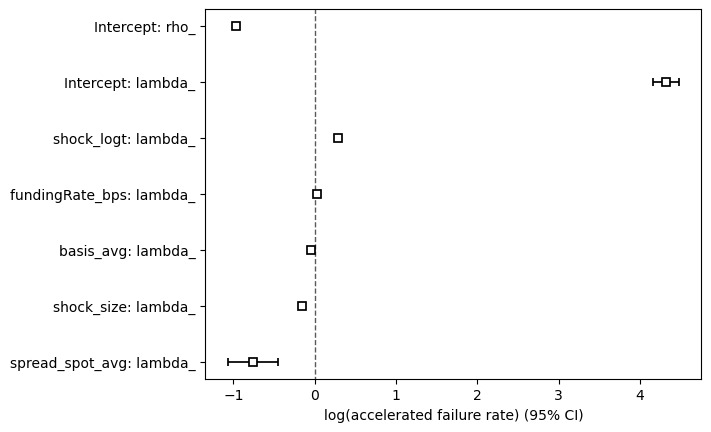

In [ ]:
aft.plot()

Text(0.5, 1.0, 'Not modelling rho_')

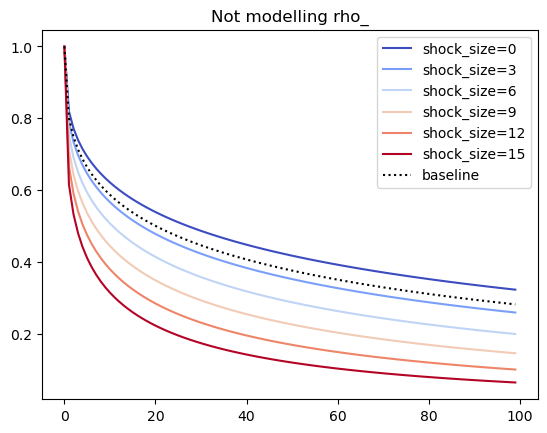

In [ ]:
times = np.arange(0, 100)
wft_not_model_rho = WeibullAFTFitter().fit(df.drop('date', axis=1), duration_col='Length', event_col='Status', ancillary=False, timeline=times)
wft_not_model_rho.plot_partial_effects_on_outcome('shock_size', range(0, 16, 3), cmap='coolwarm')
plt.title("Not modelling rho_")

suspiciously good fit... drop?

In [ ]:
from lifelines import LogNormalAFTFitter

aft_ln = LogNormalAFTFitter()
aft_ln.fit(df, "Length", "Status", formula="shock_size + shock_logt + spread_spot_avg + basis_avg + fundingRate_bps")
aft_ln.print_summary(3)

<lifelines.LogNormalAFTFitter: fitted with 16138 total observations, 10482 right-censored observations>
             duration col = 'Length'
                event col = 'Status'
   number of observations = 16138
number of events observed = 5656
           log-likelihood = -14435.310
         time fit was run = 2026-02-03 22:03:23 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                         
mu_    Intercept        3.222    25.081     0.078           3.070           3.374              21.545              29.198
       shock_size      -0.310     0.733     0.005          -0.320          -0.300               0.726               0.741
       shock_logt       0.361     1.435     0.006           0.349           0.374               1.417               1.454
       spread_spot_avg -0.512     0.599     0.151          -0.808          -0.217               0.446               0.805
       basis_avg       -0.014     0.986     0.005          -0.024          -0.004               0.976               0.996
       fundingRate_bps  0.019     1.019     0.012          -0.005           0.042               0.995               1.043
sigma_ Intercept        1.253     3.499     0.011           1.232           1.273               3.428               3.573

                        cmp to       z       p  -log2(p)
param  covariate                                        
mu_    Intercept         0.000  41.555 <0.0005       inf
       shock_size        0.000 -59.902 <0.0005       inf
       shock_logt        0.000  55.775 <0.0005       inf
       spread_spot_avg   0.000  -3.397   0.001    10.518
       basis_avg         0.000  -2.794   0.005     7.586
       fundingRate_bps   0.000   1.574   0.115     3.115
sigma_ Intercept         0.000 118.654 <0.0005       inf
---
Concordance = 0.841
AIC = 28884.620
log-likelihood ratio test = 4988.750 on 5 df
-log2(p) of ll-ratio test = inf

Text(0.5, 1.0, 'Not modelling rho_')

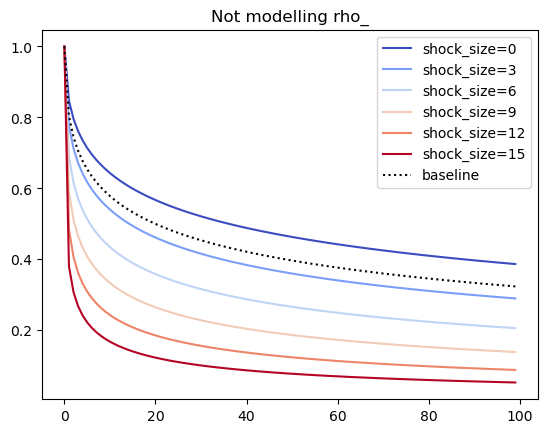

In [ ]:
times = np.arange(0, 100)
wft_not_model_rho = LogNormalAFTFitter().fit(df.drop('date', axis=1), duration_col='Length', event_col='Status', ancillary=False, timeline=times)
wft_not_model_rho.plot_partial_effects_on_outcome('shock_size', range(0, 16, 3), cmap='coolwarm')
plt.title("Not modelling rho_")

## Basis-resolution survival analysis with event-time alignment and daily checkpoints

This workflow estimates **monthly** Kaplan--Meier and Log-Logistic AFT results
without loading an entire month of raw trades at once.

For each calendar month, the code:

1. loads only `chunk_days` target dates at a time;
2. includes a short lookback and follow-up window for shock detection and censoring;
3. keeps rows only when spot or perpetual trades occur;
4. forward-fills the inactive market onto those observed trade timestamps;
5. saves only the resulting episode rows;
6. pools the episode rows at month end and fits one monthly model.

Kaplan--Meier does not require regular price spacing. The one-second KM output
grid is only a compact representation of the fitted step function for plotting;
it does not create one-second price observations.

Run one asset, contract type, and shock perspective at a time.


In [1]:
from pathlib import Path
import gc
import os

import numpy as np
import pandas as pd

from survival_analysis_basis_eventstore_v5 import plot_periodic_km
from survival_analysis_basis_pipeline_v5 import (
    MonthlyBasisSurvivalAnalysis,
    fit_loglogistic_aft_month_by_month,
    load_monthly_events,
    load_monthly_km,
)

START_DATE = "20210101"
END_DATE = "20260101"  # exclusive

BASIS_RUN_KWARGS = {
    "shock_significance": 0.001,
    "method": "lee_mykland",
    "resolution_pcts": [50, 90, 95],
    "max_duration_seconds": 120,
    "refractory_seconds": 5,
    "min_hold_seconds": 0.25,
    "basis_tolerance_bps": 0.5,
    "min_basis_shock_bps": 0.0,
    "timeline_step_seconds": 1,
    "resume": True,
    "load_followup_days": 1,
    "load_lookback_days": 1,
    "chunk_days": 14,
    "keep_chunk_events": False,
    "save_monthly_events": True,
    "compact_event_storage": True,
}

AFT_BUILD_KWARGS = {
    "shock_significance": 0.001,
    "method": "lee_mykland",
    "primary_resolution_pct": 90,
    "max_duration_seconds": 120,
    "refractory_seconds": 5,
    "min_hold_seconds": 0.25,
    "basis_tolerance_bps": 0.5,
    "min_basis_shock_bps": 0.0,
    "resume": True,
    "load_followup_days": 1,
    "load_lookback_days": 1,
    "chunk_days": 14,
    "keep_chunk_aft_data": False,
}

AFT_COVARIATES = [
    "log_shock_size_bps",
    "spread_spot_5min",
    "vol_spot_5min_pct",
    "log_volume",
]


### Checkpoint layout and storage behaviour

Passing `checkpoint_dir="sa_btc_um"` creates:

```text
sa_btc_um/
├── event_chunks/ # temporary daily episode checkpoints
├── events/       # one compressed episode parquet per completed month
├── km/           # one small monthly KM grid
├── done/         # monthly completion markers
├── manifest.csv
├── aft_chunks/   # temporary daily covariate checkpoints
├── aft_data/     # one compressed AFT input parquet per month
└── aft_fits/     # monthly coefficients, curves and percentiles
```

With `keep_chunk_events=False` and `keep_chunk_aft_data=False`, daily checkpoint
directories are deleted only after the monthly outputs and completion marker are
written safely. A crash therefore preserves completed daily chunks for the
unfinished month, while completed months retain only compact monthly files.

For the smallest KM-only run, set `save_monthly_events=False`. The monthly KM
grid and manifest are retained, but individual episode rows are discarded after
the model is fitted.


In [2]:
def add_log_transforms_to_monthly_aft_files(checkpoint_dir):
    """Add log covariates one saved month at a time without pooling data in memory."""
    aft_dir = Path(checkpoint_dir) / "aft_data"

    for path in sorted(aft_dir.glob("*.parquet")):
        frame = pd.read_parquet(path)
        if frame.empty:
            continue

        if "shock_size_bps" in frame:
            frame["log_shock_size_bps"] = np.log1p(
                frame["shock_size_bps"].clip(lower=0)
            )

        if "volume" in frame:
            frame["log_volume"] = np.log1p(
                frame["volume"].clip(lower=0)
            )

        tmp_path = path.with_name(path.stem + ".tmp.parquet")
        frame.to_parquet(tmp_path, index=False)
        os.replace(tmp_path, path)

        del frame
        gc.collect()


def load_monthly_aft_outputs(checkpoint_dir, output_type="coefficients", first=None):
    """Load only small fitted AFT output CSVs across completed months."""
    folder = Path(checkpoint_dir) / "aft_fits" / output_type
    pattern = f"{first}_*.csv" if first else "*.csv"
    frames = [pd.read_csv(path) for path in sorted(folder.glob(pattern))]
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


## BTC linear perpetual (`sa_btc_um`)


In [3]:
BTC_UM_DIR = Path("sa_btc_um")

BTC_UM_DIR.mkdir(parents=True, exist_ok=True)

bsa_btc_um = MonthlyBasisSurvivalAnalysis(
    "BTCUSDT",
    source="Binance",
    cm_um="um",
)


### One-month pilot, processed one day at a time

This still produces one January 2025 KM model. The raw trades are loaded one
target day at a time, and daily episode checkpoints are removed after the month
is saved successfully.


In [5]:
btc_um_pilot = bsa_btc_um.fit_basis_month_by_month(
    start="20250101",
    end="20250201",
    checkpoint_dir=BTC_UM_DIR,
    first="spot",
    **BASIS_RUN_KWARGS,
)

btc_um_pilot.tail()


[skip] 2025-01 (spot) already completed


,period,first,status,period_start,period_end,event_rows,unique_episodes,resolved_rows,resolution_pcts,max_duration_seconds,events_file,km_file,error,chunk_days,event_time_alignment,monthly_events_saved
115,2025-08,spot,complete,2025-08-01,2025-09-01,392247.0,130749.0,379782.0,NaN,NaN,sa_btc_um\events\spot_2025-08.parquet,sa_btc_um\km\spot_2025-08.csv,NaN,14.0,True,True
116,2025-09,spot,complete,2025-09-01,2025-10-01,314115.0,104705.0,302005.0,NaN,NaN,sa_btc_um\events\spot_2025-09.parquet,sa_btc_um\km\spot_2025-09.csv,NaN,14.0,True,True
117,2025-10,spot,complete,2025-10-01,2025-11-01,485292.0,161764.0,466321.0,NaN,NaN,sa_btc_um\events\spot_2025-10.parquet,sa_btc_um\km\spot_2025-10.csv,NaN,14.0,True,True
118,2025-11,spot,complete,2025-11-01,2025-12-01,582258.0,194086.0,562482.0,NaN,NaN,sa_btc_um\events\spot_2025-11.parquet,sa_btc_um\km\spot_2025-11.csv,NaN,14.0,True,True
119,2025-12,spot,complete,2025-12-01,2026-01-01,444234.0,148078.0,424826.0,NaN,NaN,sa_btc_um\events\spot_2025-12.parquet,sa_btc_um\km\spot_2025-12.csv,NaN,14.0,True,True


### Full monthly Kaplan--Meier run

Each monthly estimate pools all episode rows from that month, even though the
raw trades are processed in one-day chunks. Run the spot and perp cells
separately. Completed chunks and months are skipped automatically.


In [6]:
btc_um_spot_manifest = bsa_btc_um.fit_basis_month_by_month(
    start=START_DATE,
    end=END_DATE,
    checkpoint_dir=BTC_UM_DIR,
    first="spot",
    **BASIS_RUN_KWARGS,
)

btc_um_spot_manifest.tail()


[skip] 2021-01 (spot) already completed
[skip] 2021-02 (spot) already completed
[skip] 2021-03 (spot) already completed
[skip] 2021-04 (spot) already completed
[skip] 2021-05 (spot) already completed
[skip] 2021-06 (spot) already completed
[skip] 2021-07 (spot) already completed
[skip] 2021-08 (spot) already completed
[skip] 2021-09 (spot) already completed
[skip] 2021-10 (spot) already completed
[skip] 2021-11 (spot) already completed
[skip] 2021-12 (spot) already completed
[skip] 2022-01 (spot) already completed
[skip] 2022-02 (spot) already completed
[skip] 2022-03 (spot) already completed
[skip] 2022-04 (spot) already completed
[skip] 2022-05 (spot) already completed
[skip] 2022-06 (spot) already completed
[skip] 2022-07 (spot) already completed
[skip] 2022-08 (spot) already completed
[skip] 2022-09 (spot) already completed
[skip] 2022-10 (spot) already completed
[skip] 2022-11 (spot) already completed
[skip] 2022-12 (spot) already completed
[skip] 2023-01 (spot) already completed


,period,first,status,period_start,period_end,event_rows,unique_episodes,resolved_rows,resolution_pcts,max_duration_seconds,events_file,km_file,error,chunk_days,event_time_alignment,monthly_events_saved
115,2025-08,spot,complete,2025-08-01,2025-09-01,392247.0,130749.0,379782.0,NaN,NaN,sa_btc_um\events\spot_2025-08.parquet,sa_btc_um\km\spot_2025-08.csv,NaN,14.0,True,True
116,2025-09,spot,complete,2025-09-01,2025-10-01,314115.0,104705.0,302005.0,NaN,NaN,sa_btc_um\events\spot_2025-09.parquet,sa_btc_um\km\spot_2025-09.csv,NaN,14.0,True,True
117,2025-10,spot,complete,2025-10-01,2025-11-01,485292.0,161764.0,466321.0,NaN,NaN,sa_btc_um\events\spot_2025-10.parquet,sa_btc_um\km\spot_2025-10.csv,NaN,14.0,True,True
118,2025-11,spot,complete,2025-11-01,2025-12-01,582258.0,194086.0,562482.0,NaN,NaN,sa_btc_um\events\spot_2025-11.parquet,sa_btc_um\km\spot_2025-11.csv,NaN,14.0,True,True
119,2025-12,spot,complete,2025-12-01,2026-01-01,444234.0,148078.0,424826.0,NaN,NaN,sa_btc_um\events\spot_2025-12.parquet,sa_btc_um\km\spot_2025-12.csv,NaN,14.0,True,True


In [7]:
# Run only after the spot-perspective job has completed.
btc_um_perp_manifest = bsa_btc_um.fit_basis_month_by_month(
    start=START_DATE,
    end=END_DATE,
    checkpoint_dir=BTC_UM_DIR,
    first="perp",
    **BASIS_RUN_KWARGS,
)

btc_um_perp_manifest.tail()


[skip] 2021-01 (perp) already completed
[skip] 2021-02 (perp) already completed
[skip] 2021-03 (perp) already completed
[skip] 2021-04 (perp) already completed
[skip] 2021-05 (perp) already completed
[skip] 2021-06 (perp) already completed
[skip] 2021-07 (perp) already completed
[skip] 2021-08 (perp) already completed
[skip] 2021-09 (perp) already completed
[skip] 2021-10 (perp) already completed
[skip] 2021-11 (perp) already completed
[skip] 2021-12 (perp) already completed
[skip] 2022-01 (perp) already completed
[skip] 2022-02 (perp) already completed
[skip] 2022-03 (perp) already completed
[skip] 2022-04 (perp) already completed
[skip] 2022-05 (perp) already completed
[skip] 2022-06 (perp) already completed
[skip] 2022-07 (perp) already completed
[skip] 2022-08 (perp) already completed
[skip] 2022-09 (perp) already completed
[skip] 2022-10 (perp) already completed
[skip] 2022-11 (perp) already completed
[skip] 2022-12 (perp) already completed
[skip] 2023-01 (perp) already completed


,period,first,status,period_start,period_end,event_rows,unique_episodes,resolved_rows,resolution_pcts,max_duration_seconds,events_file,km_file,error,chunk_days,event_time_alignment,monthly_events_saved
115,2025-08,spot,complete,2025-08-01,2025-09-01,392247.0,130749.0,379782.0,NaN,NaN,sa_btc_um\events\spot_2025-08.parquet,sa_btc_um\km\spot_2025-08.csv,NaN,14.0,True,True
116,2025-09,spot,complete,2025-09-01,2025-10-01,314115.0,104705.0,302005.0,NaN,NaN,sa_btc_um\events\spot_2025-09.parquet,sa_btc_um\km\spot_2025-09.csv,NaN,14.0,True,True
117,2025-10,spot,complete,2025-10-01,2025-11-01,485292.0,161764.0,466321.0,NaN,NaN,sa_btc_um\events\spot_2025-10.parquet,sa_btc_um\km\spot_2025-10.csv,NaN,14.0,True,True
118,2025-11,spot,complete,2025-11-01,2025-12-01,582258.0,194086.0,562482.0,NaN,NaN,sa_btc_um\events\spot_2025-11.parquet,sa_btc_um\km\spot_2025-11.csv,NaN,14.0,True,True
119,2025-12,spot,complete,2025-12-01,2026-01-01,444234.0,148078.0,424826.0,NaN,NaN,sa_btc_um\events\spot_2025-12.parquet,sa_btc_um\km\spot_2025-12.csv,NaN,14.0,True,True


### Load and plot saved monthly KM grids

This loads only the small one-second **model output grids**. The original trade
series remains irregularly spaced and is never expanded to one-second buckets.


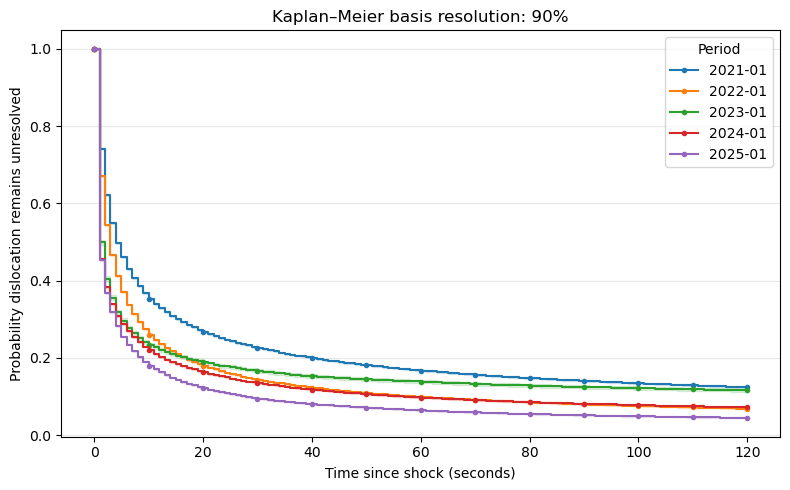

In [6]:
BTC_UM_DIR = Path("sa_btc_um")
BTC_CM_DIR = Path("sa_btc_cm")
ETH_UM_DIR = Path("sa_eth_um")
ETH_CM_DIR = Path("sa_eth_cm")
btc_um_km_spot = load_monthly_km(BTC_UM_DIR, first="spot")
btc_um_km_perp = load_monthly_km(BTC_UM_DIR, first="perp")
eth_um_km_spot = load_monthly_km(ETH_UM_DIR, first="spot")
eth_um_km_perp = load_monthly_km(ETH_UM_DIR, first="perp")

# Preserve the previous aggregate KM file locations.
btc_um_km_spot.to_csv(
    BTC_UM_DIR / "basis_km_spot_monthly_1s.csv",
    index=False,
)
btc_um_km_perp.to_csv(
    BTC_UM_DIR / "basis_km_perp_monthly_1s.csv",
    index=False,
)

eth_um_km_spot.to_csv(
    ETH_UM_DIR / "basis_km_spot_monthly_1s.csv",
    index=False,
)
eth_um_km_perp.to_csv(
    ETH_UM_DIR / "basis_km_perp_monthly_1s.csv",
    index=False,
)

selected_periods = ["2021-01", "2022-01", "2023-01", '2024-01', "2025-01"]

fig, ax = plot_periodic_km(
    btc_um_km_spot[
        btc_um_km_spot["period"].astype(str).isin(selected_periods)
    ],
    resolution_pct=90,
    first="spot",
    marker_every_seconds=10,
)


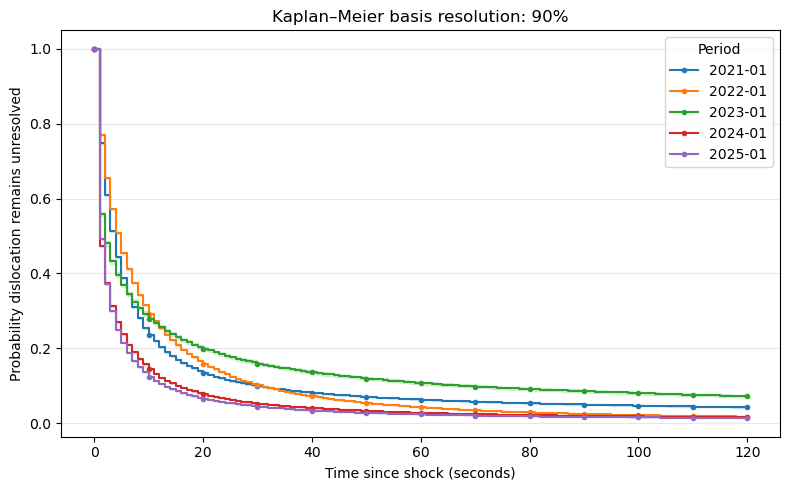

In [7]:
btc_cm_km_spot = load_monthly_km(BTC_CM_DIR, first="spot")
btc_cm_km_perp = load_monthly_km(BTC_CM_DIR, first="perp")
eth_cm_km_spot = load_monthly_km(ETH_CM_DIR, first="spot")
eth_cm_km_perp = load_monthly_km(ETH_CM_DIR, first="perp")

# Preserve the previous aggregate KM file locations.
btc_cm_km_spot.to_csv(
    BTC_CM_DIR / "basis_km_spot_monthly_1s.csv",
    index=False,
)
btc_cm_km_perp.to_csv(
    BTC_CM_DIR / "basis_km_perp_monthly_1s.csv",
    index=False,
)

eth_cm_km_spot.to_csv(
    ETH_CM_DIR / "basis_km_spot_monthly_1s.csv",
    index=False,
)
eth_cm_km_perp.to_csv(
    ETH_CM_DIR / "basis_km_perp_monthly_1s.csv",
    index=False,
)

selected_periods = ["2021-01", "2022-01", "2023-01", '2024-01', "2025-01"]

fig, ax = plot_periodic_km(
    btc_cm_km_spot[
        btc_cm_km_spot["period"].astype(str).isin(selected_periods)
    ],
    resolution_pct=90,
    first="spot",
    marker_every_seconds=10,
)


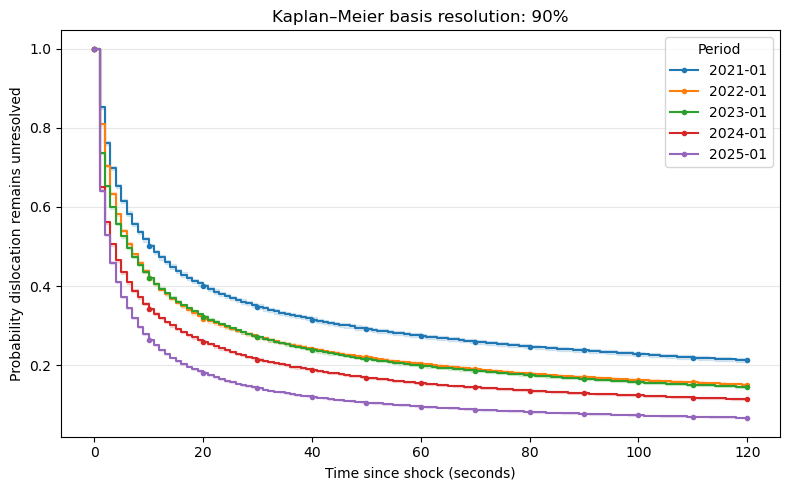

In [20]:
eth_um_km_spot = load_monthly_km(ETH_UM_DIR, first="spot")
eth_um_km_perp = load_monthly_km(ETH_UM_DIR, first="perp")

# Preserve the previous aggregate KM file locations.
eth_um_km_spot.to_csv(
    ETH_UM_DIR / "basis_km_spot_monthly_1s.csv",
    index=False,
)
btc_um_km_perp.to_csv(
    ETH_UM_DIR / "basis_km_perp_monthly_1s.csv",
    index=False,
)

selected_periods = ["2021-01", "2022-01", "2023-01", '2024-01', "2025-01"]

fig, ax = plot_periodic_km(
    eth_um_km_spot[
        eth_um_km_spot["period"].astype(str).isin(selected_periods)
    ],
    resolution_pct=90,
    first="spot",
    marker_every_seconds=10,
)


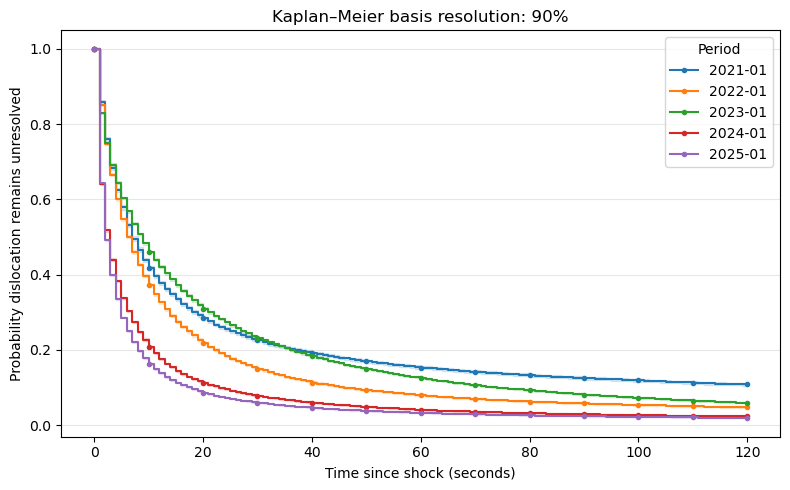

In [21]:
eth_um_km_spot = load_monthly_km(ETH_CM_DIR, first="spot")
eth_um_km_perp = load_monthly_km(ETH_CM_DIR, first="perp")

# Preserve the previous aggregate KM file locations.
eth_um_km_spot.to_csv(
    ETH_CM_DIR / "basis_km_spot_monthly_1s.csv",
    index=False,
)
btc_um_km_perp.to_csv(
    ETH_CM_DIR / "basis_km_perp_monthly_1s.csv",
    index=False,
)

selected_periods = ["2021-01", "2022-01", "2023-01", '2024-01', "2025-01"]

fig, ax = plot_periodic_km(
    eth_um_km_spot[
        eth_um_km_spot["period"].astype(str).isin(selected_periods)
    ],
    resolution_pct=90,
    first="spot",
    marker_every_seconds=10,
)


In [8]:
import math
import matplotlib.pyplot as plt
import pandas as pd


def plot_km_month_comparison(
    dfs,
    df_labels,
    months,
    resolution_pct=90,
    max_time_seconds=60,
    plots_per_row=4,
    month_column="period",
    time_column=None,
    survival_column="survival",
    figsize_per_subplot=(4.5, 3.5),
):
    """
    Compare already-separated V5 KM outputs across selected months.

    Each DataFrame corresponds to one curve, e.g.
        btc_um_km_spot
        btc_um_km_perp
        btc_cm_km_spot
        btc_cm_km_perp

    Color = contract type
    Line style = initiating market
    """

    if len(dfs) != len(df_labels):
        raise ValueError(
            "dfs and df_labels must have the same length."
        )

    if len(months) == 0:
        raise ValueError("Provide at least one month.")

    if not 1 <= plots_per_row <= 4:
        raise ValueError(
            "plots_per_row must be between 1 and 4."
        )

    # Detect KM time column if not supplied.
    if time_column is None:
        possible_time_columns = [
            "timeline",
            "time",
            "duration",
            "index",
            "time_s",
        ]

        time_column = next(
            (
                column
                for column in possible_time_columns
                if all(column in df.columns for df in dfs)
            ),
            None,
        )

        if time_column is None:
            raise KeyError(
                "Could not identify the KM time column. "
                "Pass time_column explicitly."
            )

    required_columns = {
        month_column,
        time_column,
        survival_column,
        "resolution_pct",
    }

    for label, df in zip(df_labels, dfs):
        missing = required_columns.difference(df.columns)
        if missing:
            raise KeyError(
                f"{label} is missing columns: {sorted(missing)}"
            )

    ncols = min(plots_per_row, len(months))
    nrows = math.ceil(len(months) / ncols)

    subplot_width, subplot_height = figsize_per_subplot

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(subplot_width * ncols, subplot_height * nrows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    axes_flat = axes.ravel()

    # Same contract type -> same color
    contract_colors = {
        "Linear": "tab:blue",
        "Inverse": "tab:orange",
    }

    # Same originating market -> same line style
    origin_styles = {
        "spot": "-",
        "perp": "--",
    }

    for panel_index, selected_month in enumerate(months):
        ax = axes_flat[panel_index]
        curves_plotted = 0

        for df, label in zip(dfs, df_labels):
            data = df.copy()

            data["_plot_month"] = (
                pd.to_datetime(data[month_column])
                .dt.to_period("M")
                .astype(str)
            )

            group = data[
                data["_plot_month"].eq(str(selected_month))
                & data["resolution_pct"].eq(resolution_pct)
            ].copy()

            group = group[
                group[time_column].le(max_time_seconds)
            ].sort_values(time_column)

            if group.empty:
                continue

            # Parse label like "Linear: spot"
            if ":" in label:
                contract_type, origin = [
                    piece.strip() for piece in label.split(":", 1)
                ]
            else:
                contract_type = label.strip()
                origin = ""

            color = contract_colors.get(contract_type, None)
            linestyle = origin_styles.get(origin.lower(), "-")

            ax.step(
                group[time_column],
                group[survival_column],
                where="post",
                color=color,
                linestyle=linestyle,
                linewidth=1.8,
                label=label,
            )

            curves_plotted += 1

        ax.set_title(selected_month)
        ax.set_xlim(0, max_time_seconds)
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)

        if panel_index % ncols == 0:
            ax.set_ylabel("Probability unresolved")

        if panel_index // ncols == nrows - 1:
            ax.set_xlabel("Seconds since basis displacement")

        if curves_plotted == 0:
            ax.text(
                0.5,
                0.5,
                "No matching data",
                transform=ax.transAxes,
                ha="center",
                va="center",
            )

    for unused_index in range(len(months), len(axes_flat)):
        fig.delaxes(axes_flat[unused_index])

    # Shared legend
    handles, labels = [], []
    for ax in axes_flat[:len(months)]:
        panel_handles, panel_labels = ax.get_legend_handles_labels()
        for handle, label in zip(panel_handles, panel_labels):
            if label not in labels:
                handles.append(handle)
                labels.append(label)

    if handles:
        fig.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.02),
            ncol=min(4, len(labels)),
            frameon=False,
        )

    fig.suptitle(
        f"Kaplan–Meier curves for {resolution_pct}% basis resolution",
        y=1.07 if nrows == 1 else 1.03,
    )

    fig.tight_layout()
    plt.show()

    return fig, axes

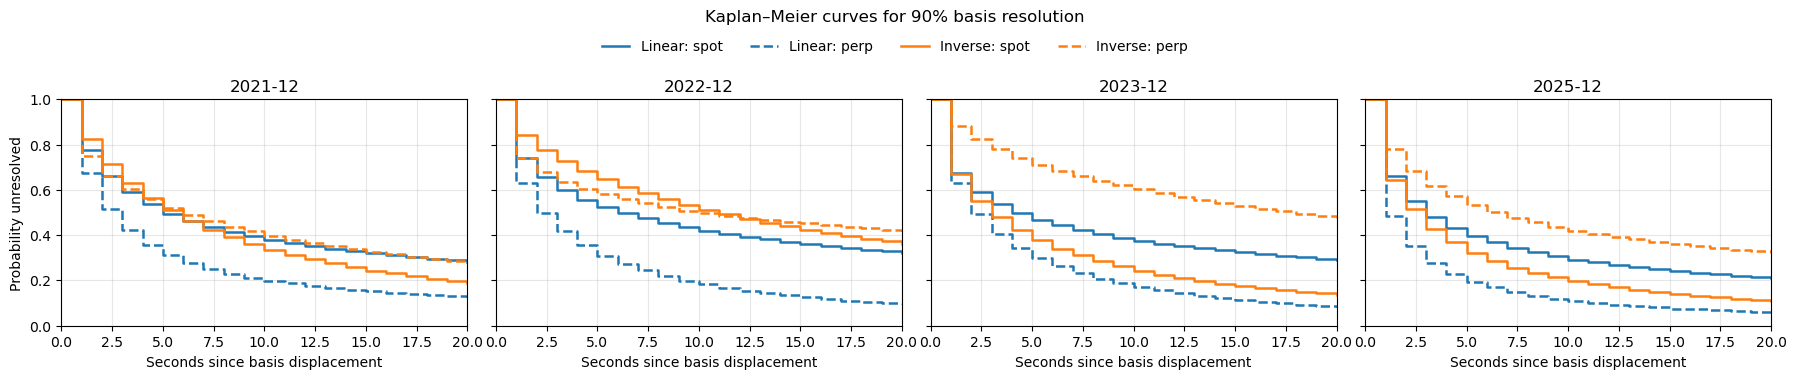

In [12]:
fig, axes = plot_km_month_comparison(
    dfs=[
        eth_um_km_spot,
        eth_um_km_perp,
        eth_cm_km_spot,
        eth_cm_km_perp,
    ],
    df_labels=[
        "Linear: spot",
        "Linear: perp",
        "Inverse: spot",
        "Inverse: perp",
    ],
    months=[
        "2021-12",
        "2022-12",
        "2023-12",
        "2025-12",
    ],
    resolution_pct=90,
    max_time_seconds=20,
    plots_per_row=4,
)

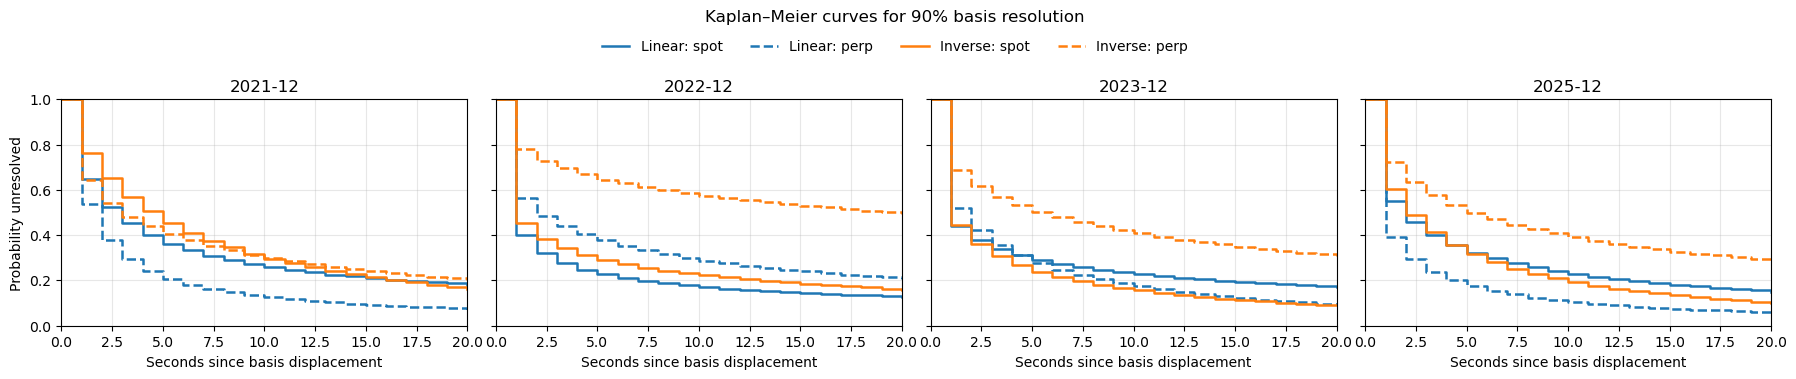

In [13]:
fig, axes = plot_km_month_comparison(
    dfs=[
        btc_um_km_spot,
        btc_um_km_perp,
        btc_cm_km_spot,
        btc_cm_km_perp,
    ],
    df_labels=[
        "Linear: spot",
        "Linear: perp",
        "Inverse: spot",
        "Inverse: perp",
    ],
    months=[
        "2021-12",
        "2022-12",
        "2023-12",
        "2025-12",
    ],
    resolution_pct=90,
    max_time_seconds=20,
    plots_per_row=4,
)

### Monthly Log-Logistic AFT data and fits

AFT covariates are also built one target day at a time. Only episode-level
covariate rows are pooled at month end, after which one monthly Log-Logistic AFT
model is fitted. Run one shock perspective at a time.


In [13]:
# btc_um_aft_spot_manifest = 
bsa_btc_um.build_aft_data_month_by_month(
    start=START_DATE,
    end=END_DATE,
    checkpoint_dir=BTC_UM_DIR,
    first="spot",
    **AFT_BUILD_KWARGS,
)

# btc_um_aft_spot_manifest.tail()


  [AFT chunk] 2021-01-01
Processing 16 files...
Processing batch 1/1
Combining results...
Processing 16 files...
Processing batch 1/1
Combining results...
lee_mykland 3.0 0.99 None 0.001 True spot
[failed AFT data] 2021-01: AttributeError("'NoneType' object has no attribute 'df_trades_spots'")


AttributeError: 'NoneType' object has no attribute 'df_trades_spots'

In [ ]:
# Optional second perspective; run after the spot AFT-data job.
# btc_um_aft_perp_manifest = 
bsa_btc_um.build_aft_data_month_by_month(
    start=START_DATE,
    end=END_DATE,
    checkpoint_dir=BTC_UM_DIR,
    first="perp",
    **AFT_BUILD_KWARGS,
)

# btc_um_aft_perp_manifest.tail()


In [ ]:
add_log_transforms_to_monthly_aft_files(BTC_UM_DIR)

# btc_um_aft_fit_manifest = 
fit_loglogistic_aft_month_by_month(
    aft_data_dir=BTC_UM_DIR / "aft_data",
    output_dir=BTC_UM_DIR / "aft_fits",
    covariates=AFT_COVARIATES,
    resolution_pct=90,
    max_duration_seconds=120,
    timeline_step_seconds=1,
    percentile_step=1,
    min_episodes=100,
    ancillary=False,
    resume=True,
)

# btc_um_aft_fit_manifest.tail()


In [ ]:
btc_um_aft_coefficients = load_monthly_aft_outputs(
    BTC_UM_DIR,
    output_type="coefficients",
)

btc_um_aft_curves = load_monthly_aft_outputs(
    BTC_UM_DIR,
    output_type="curves",
)

btc_um_aft_percentiles = load_monthly_aft_outputs(
    BTC_UM_DIR,
    output_type="percentiles",
)

btc_um_aft_coefficients.to_csv(
    BTC_UM_DIR / "loglogistic_coefficients_monthly.csv",
    index=False,
)
btc_um_aft_curves.to_csv(
    BTC_UM_DIR / "loglogistic_curves_monthly_1s.csv",
    index=False,
)
btc_um_aft_percentiles.to_csv(
    BTC_UM_DIR / "loglogistic_percentiles_monthly.csv",
    index=False,
)

btc_um_aft_coefficients.head()


## BTC inverse perpetual (`sa_btc_cm`)


In [ ]:
BTC_CM_DIR = Path("sa_btc_cm")
BTC_CM_DIR.mkdir(parents=True, exist_ok=True)

bsa_btc_cm = MonthlyBasisSurvivalAnalysis(
    "BTCUSDT",
    source="Binance",
    cm_um="cm",
)


In [6]:
# btc_cm_spot_manifest = 
bsa_btc_cm.fit_basis_month_by_month(
    start=START_DATE,
    end=END_DATE,
    checkpoint_dir=BTC_CM_DIR,
    first="spot",
    **BASIS_RUN_KWARGS,
)

# btc_cm_spot_manifest.tail()


[start] 2021-01 (spot); processing 14-day chunk(s)
  [chunk] 2021-01-01 to 2021-01-15
Processing 16 files...
Processing batch 1/1
Combining results...
Processing 16 files...
Processing batch 1/1
Combining results...
lee_mykland 3.0 0.99 None 0.001 True spot
  [chunk] 2021-01-15 to 2021-01-29
Processing 16 files...
Processing batch 1/1
Combining results...
Processing 16 files...
Processing batch 1/1
Combining results...
lee_mykland 3.0 0.99 None 0.001 True spot
  [chunk] 2021-01-29 to 2021-02-01
Processing 5 files...
Processing batch 1/1
Combining results...
Processing 5 files...
Processing batch 1/1
Combining results...
lee_mykland 3.0 0.99 None 0.001 True spot
[saved] 2021-01: 140,257 unique episodes
[start] 2021-02 (spot); processing 14-day chunk(s)
  [chunk] 2021-02-01 to 2021-02-15
Processing 16 files...
Processing batch 1/1
Combining results...
Processing 16 files...
Processing batch 1/1
Combining results...
lee_mykland 3.0 0.99 None 0.001 True spot
  [chunk] 2021-02-15 to 2021-03

,period,first,status,period_start,period_end,event_rows,unique_episodes,resolved_rows,chunk_days,event_time_alignment,monthly_events_saved,events_file,km_file
0,2021-01,spot,complete,2021-01-01,2021-02-01,420771,140257,406554,14,True,True,sa_btc_cm\events\spot_2021-01.parquet,sa_btc_cm\km\spot_2021-01.csv
1,2021-02,spot,complete,2021-02-01,2021-03-01,385938,128646,376987,14,True,True,sa_btc_cm\events\spot_2021-02.parquet,sa_btc_cm\km\spot_2021-02.csv
2,2021-03,spot,complete,2021-03-01,2021-04-01,583050,194350,575290,14,True,True,sa_btc_cm\events\spot_2021-03.parquet,sa_btc_cm\km\spot_2021-03.csv
3,2021-04,spot,complete,2021-04-01,2021-05-01,720264,240088,711488,14,True,True,sa_btc_cm\events\spot_2021-04.parquet,sa_btc_cm\km\spot_2021-04.csv
4,2021-05,spot,complete,2021-05-01,2021-06-01,598656,199552,585612,14,True,True,sa_btc_cm\events\spot_2021-05.parquet,sa_btc_cm\km\spot_2021-05.csv
5,2021-06,spot,complete,2021-06-01,2021-07-01,504768,168256,497025,14,True,True,sa_btc_cm\events\spot_2021-06.parquet,sa_btc_cm\km\spot_2021-06.csv
6,2021-07,spot,complete,2021-07-01,2021-08-01,578265,192755,570041,14,True,True,sa_btc_cm\events\spot_2021-07.parquet,sa_btc_cm\km\spot_2021-07.csv
7,2021-08,spot,complete,2021-08-01,2021-09-01,733971,244657,726491,14,True,True,sa_btc_cm\events\spot_2021-08.parquet,sa_btc_cm\km\spot_2021-08.csv
8,2021-09,spot,complete,2021-09-01,2021-10-01,652614,217538,643275,14,True,True,sa_btc_cm\events\spot_2021-09.parquet,sa_btc_cm\km\spot_2021-09.csv
9,2021-10,spot,complete,2021-10-01,2021-11-01,650820,216940,642306,14,True,True,sa_btc_cm\events\spot_2021-10.parquet,sa_btc_cm\km\spot_2021-10.csv


In [4]:
# Run separately after the spot-perspective job.
# btc_cm_perp_manifest = 
bsa_btc_cm.fit_basis_month_by_month(
    start=START_DATE,
    end=END_DATE,
    checkpoint_dir=BTC_CM_DIR,
    first="perp",
    **BASIS_RUN_KWARGS,
)

# btc_cm_perp_manifest.tail()


[skip] 2021-01 (perp) already completed
[skip] 2021-02 (perp) already completed
[skip] 2021-03 (perp) already completed
[skip] 2021-04 (perp) already completed
[skip] 2021-05 (perp) already completed
[skip] 2021-06 (perp) already completed
[skip] 2021-07 (perp) already completed
[skip] 2021-08 (perp) already completed
[skip] 2021-09 (perp) already completed
[skip] 2021-10 (perp) already completed
[skip] 2021-11 (perp) already completed
[skip] 2021-12 (perp) already completed
[skip] 2022-01 (perp) already completed
[skip] 2022-02 (perp) already completed
[skip] 2022-03 (perp) already completed
[skip] 2022-04 (perp) already completed
[skip] 2022-05 (perp) already completed
[skip] 2022-06 (perp) already completed
[skip] 2022-07 (perp) already completed
[skip] 2022-08 (perp) already completed
[skip] 2022-09 (perp) already completed
[skip] 2022-10 (perp) already completed
[skip] 2022-11 (perp) already completed
[skip] 2022-12 (perp) already completed
[skip] 2023-01 (perp) already completed


,period,first,status,period_start,period_end,event_rows,unique_episodes,resolved_rows,chunk_days,event_time_alignment,monthly_events_saved,events_file,km_file
0,2021-01,perp,complete,2021-01-01,2021-02-01,209055,69685,181687,14,True,True,sa_btc_cm\events\perp_2021-01.parquet,sa_btc_cm\km\perp_2021-01.csv
1,2021-02,perp,complete,2021-02-01,2021-03-01,205605,68535,183264,14,True,True,sa_btc_cm\events\perp_2021-02.parquet,sa_btc_cm\km\perp_2021-02.csv
2,2021-03,perp,complete,2021-03-01,2021-04-01,261444,87148,237361,14,True,True,sa_btc_cm\events\perp_2021-03.parquet,sa_btc_cm\km\perp_2021-03.csv
3,2021-04,perp,complete,2021-04-01,2021-05-01,193932,64644,178018,14,True,True,sa_btc_cm\events\perp_2021-04.parquet,sa_btc_cm\km\perp_2021-04.csv
4,2021-05,perp,complete,2021-05-01,2021-06-01,212154,70718,187285,14,True,True,sa_btc_cm\events\perp_2021-05.parquet,sa_btc_cm\km\perp_2021-05.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2025-08,spot,complete,2025-08-01,2025-09-01,392235,130745,386468,14,True,True,sa_btc_cm\events\spot_2025-08.parquet,sa_btc_cm\km\spot_2025-08.csv
116,2025-09,spot,complete,2025-09-01,2025-10-01,314094,104698,307676,14,True,True,sa_btc_cm\events\spot_2025-09.parquet,sa_btc_cm\km\spot_2025-09.csv
117,2025-10,spot,complete,2025-10-01,2025-11-01,485355,161785,478129,14,True,True,sa_btc_cm\events\spot_2025-10.parquet,sa_btc_cm\km\spot_2025-10.csv
118,2025-11,spot,complete,2025-11-01,2025-12-01,582285,194095,577299,14,True,True,sa_btc_cm\events\spot_2025-11.parquet,sa_btc_cm\km\spot_2025-11.csv


In [ ]:
btc_cm_km_spot = load_monthly_km(BTC_CM_DIR, first="spot")
btc_cm_km_perp = load_monthly_km(BTC_CM_DIR, first="perp")

btc_cm_km_spot.to_csv(
    BTC_CM_DIR / "basis_km_spot_monthly_1s.csv",
    index=False,
)
btc_cm_km_perp.to_csv(
    BTC_CM_DIR / "basis_km_perp_monthly_1s.csv",
    index=False,
)


In [ ]:
# btc_cm_aft_spot_manifest = 
bsa_btc_cm.build_aft_data_month_by_month(
    start=START_DATE,
    end=END_DATE,
    checkpoint_dir=BTC_CM_DIR,
    first="spot",
    **AFT_BUILD_KWARGS,
)

# Run separately if the perp perspective is required.
# btc_cm_aft_perp_manifest = 
bsa_btc_cm.build_aft_data_month_by_month(
    start=START_DATE,
    end=END_DATE,
    checkpoint_dir=BTC_CM_DIR,
    first="perp",
    **AFT_BUILD_KWARGS,
)


In [ ]:
add_log_transforms_to_monthly_aft_files(BTC_CM_DIR)

btc_cm_aft_fit_manifest = fit_loglogistic_aft_month_by_month(
    aft_data_dir=BTC_CM_DIR / "aft_data",
    output_dir=BTC_CM_DIR / "aft_fits",
    covariates=AFT_COVARIATES,
    resolution_pct=90,
    max_duration_seconds=120,
    timeline_step_seconds=1,
    percentile_step=1,
    min_episodes=100,
    ancillary=False,
    resume=True,
)

btc_cm_aft_fit_manifest.tail()


## ETH linear perpetual (`sa_eth_um`)

The earlier notebook accidentally wrote the ETH outputs into `sa_btc_um`. This section uses the corresponding ETH directory instead.


In [3]:
ETH_UM_DIR = Path("sa_eth_um")
ETH_UM_DIR.mkdir(parents=True, exist_ok=True)

bsa_eth_um = MonthlyBasisSurvivalAnalysis(
    "ETHUSDT",
    source="Binance",
    cm_um="um",
)


In [4]:
# eth_um_spot_manifest = 
bsa_eth_um.fit_basis_month_by_month(
    start=START_DATE,
    end=END_DATE,
    checkpoint_dir=ETH_UM_DIR,
    first="spot",
    **BASIS_RUN_KWARGS,
)

# eth_um_spot_manifest.tail()


[skip] 2021-01 (spot) already completed
[skip] 2021-02 (spot) already completed
[skip] 2021-03 (spot) already completed
[skip] 2021-04 (spot) already completed
[skip] 2021-05 (spot) already completed
[skip] 2021-06 (spot) already completed
[skip] 2021-07 (spot) already completed
[skip] 2021-08 (spot) already completed
[skip] 2021-09 (spot) already completed
[skip] 2021-10 (spot) already completed
[skip] 2021-11 (spot) already completed
[skip] 2021-12 (spot) already completed
[skip] 2022-01 (spot) already completed
[skip] 2022-02 (spot) already completed
[skip] 2022-03 (spot) already completed
[skip] 2022-04 (spot) already completed
[start] 2022-05 (spot); processing 14-day chunk(s)
  [chunk] 2022-05-01 to 2022-05-15
Processing 16 files...
Processing batch 1/1
Combining results...
Processing 16 files...
Processing batch 1/1
Combining results...
lee_mykland 3.0 0.99 None 0.001 True spot
  [chunk] 2022-05-15 to 2022-05-29
Processing 16 files...
Processing batch 1/1
Combining results...
Pr

,period,first,status,period_start,period_end,event_rows,unique_episodes,resolved_rows,chunk_days,event_time_alignment,monthly_events_saved,events_file,km_file
0,2021-01,spot,complete,2021-01-01,2021-02-01,89484,29828,74560,14,True,True,sa_eth_um\events\spot_2021-01.parquet,sa_eth_um\km\spot_2021-01.csv
1,2021-02,spot,complete,2021-02-01,2021-03-01,92106,30702,81768,14,True,True,sa_eth_um\events\spot_2021-02.parquet,sa_eth_um\km\spot_2021-02.csv
2,2021-03,spot,complete,2021-03-01,2021-04-01,124644,41548,113832,14,True,True,sa_eth_um\events\spot_2021-03.parquet,sa_eth_um\km\spot_2021-03.csv
3,2021-04,spot,complete,2021-04-01,2021-05-01,236010,78670,215988,14,True,True,sa_eth_um\events\spot_2021-04.parquet,sa_eth_um\km\spot_2021-04.csv
4,2021-05,spot,complete,2021-05-01,2021-06-01,310440,103480,271571,14,True,True,sa_eth_um\events\spot_2021-05.parquet,sa_eth_um\km\spot_2021-05.csv
5,2021-06,spot,complete,2021-06-01,2021-07-01,211467,70489,186877,14,True,True,sa_eth_um\events\spot_2021-06.parquet,sa_eth_um\km\spot_2021-06.csv
6,2021-07,spot,complete,2021-07-01,2021-08-01,235065,78355,214431,14,True,True,sa_eth_um\events\spot_2021-07.parquet,sa_eth_um\km\spot_2021-07.csv
7,2021-08,spot,complete,2021-08-01,2021-09-01,374640,124880,347534,14,True,True,sa_eth_um\events\spot_2021-08.parquet,sa_eth_um\km\spot_2021-08.csv
8,2021-09,spot,complete,2021-09-01,2021-10-01,251973,83991,228993,14,True,True,sa_eth_um\events\spot_2021-09.parquet,sa_eth_um\km\spot_2021-09.csv
9,2021-10,spot,complete,2021-10-01,2021-11-01,299106,99702,276322,14,True,True,sa_eth_um\events\spot_2021-10.parquet,sa_eth_um\km\spot_2021-10.csv


In [5]:
# Run separately after the spot-perspective job.
# eth_um_perp_manifest = 
bsa_eth_um.fit_basis_month_by_month(
    start=START_DATE,
    end=END_DATE,
    checkpoint_dir=ETH_UM_DIR,
    first="perp",
    **BASIS_RUN_KWARGS,
)

# eth_um_perp_manifest.tail()


[start] 2021-01 (perp); processing 14-day chunk(s)
  [chunk] 2021-01-01 to 2021-01-15
Processing 16 files...
Processing batch 1/1
Combining results...
Processing 16 files...
Processing batch 1/1
Combining results...
lee_mykland 3.0 0.99 None 0.001 True perp
  [chunk] 2021-01-15 to 2021-01-29
Processing 16 files...
Processing batch 1/1
Combining results...
Processing 16 files...
Processing batch 1/1
Combining results...
lee_mykland 3.0 0.99 None 0.001 True perp
  [chunk] 2021-01-29 to 2021-02-01
Processing 5 files...
Processing batch 1/1
Combining results...
Processing 5 files...
Processing batch 1/1
Combining results...
lee_mykland 3.0 0.99 None 0.001 True perp
[saved] 2021-01: 47,905 unique episodes
[start] 2021-02 (perp); processing 14-day chunk(s)
  [chunk] 2021-02-01 to 2021-02-15
Processing 16 files...
Processing batch 1/1
Combining results...
Processing 16 files...
Processing batch 1/1
Combining results...
lee_mykland 3.0 0.99 None 0.001 True perp
  [chunk] 2021-02-15 to 2021-03-

,period,first,status,period_start,period_end,event_rows,unique_episodes,resolved_rows,chunk_days,event_time_alignment,monthly_events_saved,events_file,km_file
0,2021-01,perp,complete,2021-01-01,2021-02-01,143715,47905,128566,14,True,True,sa_eth_um\events\perp_2021-01.parquet,sa_eth_um\km\perp_2021-01.csv
1,2021-02,perp,complete,2021-02-01,2021-03-01,186114,62038,173447,14,True,True,sa_eth_um\events\perp_2021-02.parquet,sa_eth_um\km\perp_2021-02.csv
2,2021-03,perp,complete,2021-03-01,2021-04-01,236403,78801,226093,14,True,True,sa_eth_um\events\perp_2021-03.parquet,sa_eth_um\km\perp_2021-03.csv
3,2021-04,perp,complete,2021-04-01,2021-05-01,288342,96114,275114,14,True,True,sa_eth_um\events\perp_2021-04.parquet,sa_eth_um\km\perp_2021-04.csv
4,2021-05,perp,complete,2021-05-01,2021-06-01,356388,118796,327307,14,True,True,sa_eth_um\events\perp_2021-05.parquet,sa_eth_um\km\perp_2021-05.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2025-08,spot,complete,2025-08-01,2025-09-01,432921,144307,398870,14,True,True,sa_eth_um\events\spot_2025-08.parquet,sa_eth_um\km\spot_2025-08.csv
116,2025-09,spot,complete,2025-09-01,2025-10-01,358716,119572,336394,14,True,True,sa_eth_um\events\spot_2025-09.parquet,sa_eth_um\km\spot_2025-09.csv
117,2025-10,spot,complete,2025-10-01,2025-11-01,456174,152058,424687,14,True,True,sa_eth_um\events\spot_2025-10.parquet,sa_eth_um\km\spot_2025-10.csv
118,2025-11,spot,complete,2025-11-01,2025-12-01,386874,128958,351297,14,True,True,sa_eth_um\events\spot_2025-11.parquet,sa_eth_um\km\spot_2025-11.csv


In [ ]:
eth_um_km_spot = load_monthly_km(ETH_UM_DIR, first="spot")
eth_um_km_perp = load_monthly_km(ETH_UM_DIR, first="perp")

eth_um_km_spot.to_csv(
    ETH_UM_DIR / "basis_km_spot_monthly_1s.csv",
    index=False,
)
eth_um_km_perp.to_csv(
    ETH_UM_DIR / "basis_km_perp_monthly_1s.csv",
    index=False,
)


In [ ]:
eth_um_aft_spot_manifest = bsa_eth_um.build_aft_data_month_by_month(
    start=START_DATE,
    end=END_DATE,
    checkpoint_dir=ETH_UM_DIR,
    first="spot",
    **AFT_BUILD_KWARGS,
)

# Run separately if the perp perspective is required.
eth_um_aft_perp_manifest = bsa_eth_um.build_aft_data_month_by_month(
    start=START_DATE,
    end=END_DATE,
    checkpoint_dir=ETH_UM_DIR,
    first="perp",
    **AFT_BUILD_KWARGS,
)


In [6]:
ETH_CM_DIR = Path("sa_eth_cm")
ETH_CM_DIR.mkdir(parents=True, exist_ok=True)

bsa_eth_cm = MonthlyBasisSurvivalAnalysis(
    "ETHUSDT",
    source="Binance",
    cm_um="cm",
)


In [7]:
# eth_um_spot_manifest = 
bsa_eth_cm.fit_basis_month_by_month(
    start=START_DATE,
    end=END_DATE,
    checkpoint_dir=ETH_CM_DIR,
    first="spot",
    **BASIS_RUN_KWARGS,
)

# eth_um_spot_manifest.tail()


[start] 2021-01 (spot); processing 14-day chunk(s)
  [chunk] 2021-01-01 to 2021-01-15
Processing 16 files...
Processing batch 1/1
Combining results...
Processing 16 files...
Processing batch 1/1
Combining results...
lee_mykland 3.0 0.99 None 0.001 True spot
  [chunk] 2021-01-15 to 2021-01-29
Processing 16 files...
Processing batch 1/1
Combining results...
Processing 16 files...
Processing batch 1/1
Combining results...
lee_mykland 3.0 0.99 None 0.001 True spot
  [chunk] 2021-01-29 to 2021-02-01
Processing 5 files...
Processing batch 1/1
Combining results...
Processing 5 files...
Processing batch 1/1
Combining results...
lee_mykland 3.0 0.99 None 0.001 True spot
[saved] 2021-01: 29,828 unique episodes
[start] 2021-02 (spot); processing 14-day chunk(s)
  [chunk] 2021-02-01 to 2021-02-15
Processing 16 files...
Processing batch 1/1
Combining results...
Processing 16 files...
Processing batch 1/1
Combining results...
lee_mykland 3.0 0.99 None 0.001 True spot
  [chunk] 2021-02-15 to 2021-03-

,period,first,status,period_start,period_end,event_rows,unique_episodes,resolved_rows,chunk_days,event_time_alignment,monthly_events_saved,events_file,km_file
0,2021-01,spot,complete,2021-01-01,2021-02-01,89484,29828,81854,14,True,True,sa_eth_cm\events\spot_2021-01.parquet,sa_eth_cm\km\spot_2021-01.csv
1,2021-02,spot,complete,2021-02-01,2021-03-01,92055,30685,87409,14,True,True,sa_eth_cm\events\spot_2021-02.parquet,sa_eth_cm\km\spot_2021-02.csv
2,2021-03,spot,complete,2021-03-01,2021-04-01,124584,41528,120842,14,True,True,sa_eth_cm\events\spot_2021-03.parquet,sa_eth_cm\km\spot_2021-03.csv
3,2021-04,spot,complete,2021-04-01,2021-05-01,235974,78658,229642,14,True,True,sa_eth_cm\events\spot_2021-04.parquet,sa_eth_cm\km\spot_2021-04.csv
4,2021-05,spot,complete,2021-05-01,2021-06-01,310497,103499,296359,14,True,True,sa_eth_cm\events\spot_2021-05.parquet,sa_eth_cm\km\spot_2021-05.csv
5,2021-06,spot,complete,2021-06-01,2021-07-01,211482,70494,205546,14,True,True,sa_eth_cm\events\spot_2021-06.parquet,sa_eth_cm\km\spot_2021-06.csv
6,2021-07,spot,complete,2021-07-01,2021-08-01,235224,78408,229517,14,True,True,sa_eth_cm\events\spot_2021-07.parquet,sa_eth_cm\km\spot_2021-07.csv
7,2021-08,spot,complete,2021-08-01,2021-09-01,374676,124892,368185,14,True,True,sa_eth_cm\events\spot_2021-08.parquet,sa_eth_cm\km\spot_2021-08.csv
8,2021-09,spot,complete,2021-09-01,2021-10-01,251967,83989,245995,14,True,True,sa_eth_cm\events\spot_2021-09.parquet,sa_eth_cm\km\spot_2021-09.csv
9,2021-10,spot,complete,2021-10-01,2021-11-01,299166,99722,293715,14,True,True,sa_eth_cm\events\spot_2021-10.parquet,sa_eth_cm\km\spot_2021-10.csv


In [8]:
# Run separately after the spot-perspective job.
# eth_um_perp_manifest = 
bsa_eth_cm.fit_basis_month_by_month(
    start=START_DATE,
    end=END_DATE,
    checkpoint_dir=ETH_CM_DIR,
    first="perp",
    **BASIS_RUN_KWARGS,
)

# eth_um_perp_manifest.tail()


[start] 2021-01 (perp); processing 14-day chunk(s)
  [chunk] 2021-01-01 to 2021-01-15
Processing 16 files...
Processing batch 1/1
Combining results...
Processing 16 files...
Processing batch 1/1
Combining results...
lee_mykland 3.0 0.99 None 0.001 True perp
  [chunk] 2021-01-15 to 2021-01-29
Processing 16 files...
Processing batch 1/1
Combining results...
Processing 16 files...
Processing batch 1/1
Combining results...
lee_mykland 3.0 0.99 None 0.001 True perp
  [chunk] 2021-01-29 to 2021-02-01
Processing 5 files...
Processing batch 1/1
Combining results...
Processing 5 files...
Processing batch 1/1
Combining results...
lee_mykland 3.0 0.99 None 0.001 True perp
[saved] 2021-01: 36,106 unique episodes
[start] 2021-02 (perp); processing 14-day chunk(s)
  [chunk] 2021-02-01 to 2021-02-15
Processing 16 files...
Processing batch 1/1
Combining results...
Processing 16 files...
Processing batch 1/1
Combining results...
lee_mykland 3.0 0.99 None 0.001 True perp
  [chunk] 2021-02-15 to 2021-03-

,period,first,status,period_start,period_end,event_rows,unique_episodes,resolved_rows,chunk_days,event_time_alignment,monthly_events_saved,events_file,km_file
0,2021-01,perp,complete,2021-01-01,2021-02-01,108318,36106,83735,14,True,True,sa_eth_cm\events\perp_2021-01.parquet,sa_eth_cm\km\perp_2021-01.csv
1,2021-02,perp,complete,2021-02-01,2021-03-01,154938,51646,132230,14,True,True,sa_eth_cm\events\perp_2021-02.parquet,sa_eth_cm\km\perp_2021-02.csv
2,2021-03,perp,complete,2021-03-01,2021-04-01,167721,55907,142992,14,True,True,sa_eth_cm\events\perp_2021-03.parquet,sa_eth_cm\km\perp_2021-03.csv
3,2021-04,perp,complete,2021-04-01,2021-05-01,214878,71626,187332,14,True,True,sa_eth_cm\events\perp_2021-04.parquet,sa_eth_cm\km\perp_2021-04.csv
4,2021-05,perp,complete,2021-05-01,2021-06-01,308316,102772,260279,14,True,True,sa_eth_cm\events\perp_2021-05.parquet,sa_eth_cm\km\perp_2021-05.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2025-08,spot,complete,2025-08-01,2025-09-01,432993,144331,426169,14,True,True,sa_eth_cm\events\spot_2025-08.parquet,sa_eth_cm\km\spot_2025-08.csv
116,2025-09,spot,complete,2025-09-01,2025-10-01,358680,119560,352059,14,True,True,sa_eth_cm\events\spot_2025-09.parquet,sa_eth_cm\km\spot_2025-09.csv
117,2025-10,spot,complete,2025-10-01,2025-11-01,456174,152058,447196,14,True,True,sa_eth_cm\events\spot_2025-10.parquet,sa_eth_cm\km\spot_2025-10.csv
118,2025-11,spot,complete,2025-11-01,2025-12-01,386880,128960,379778,14,True,True,sa_eth_cm\events\spot_2025-11.parquet,sa_eth_cm\km\spot_2025-11.csv


In [ ]:
eth_um_km_spot = load_monthly_km(ETH_UM_DIR, first="spot")
eth_um_km_perp = load_monthly_km(ETH_UM_DIR, first="perp")

eth_um_km_spot.to_csv(
    ETH_UM_DIR / "basis_km_spot_monthly_1s.csv",
    index=False,
)
eth_um_km_perp.to_csv(
    ETH_UM_DIR / "basis_km_perp_monthly_1s.csv",
    index=False,
)


In [ ]:
eth_um_aft_spot_manifest = bsa_eth_um.build_aft_data_month_by_month(
    start=START_DATE,
    end=END_DATE,
    checkpoint_dir=ETH_UM_DIR,
    first="spot",
    **AFT_BUILD_KWARGS,
)

# Run separately if the perp perspective is required.
eth_um_aft_perp_manifest = bsa_eth_um.build_aft_data_month_by_month(
    start=START_DATE,
    end=END_DATE,
    checkpoint_dir=ETH_UM_DIR,
    first="perp",
    **AFT_BUILD_KWARGS,
)


In [ ]:
add_log_transforms_to_monthly_aft_files(ETH_UM_DIR)

eth_um_aft_fit_manifest = fit_loglogistic_aft_month_by_month(
    aft_data_dir=ETH_UM_DIR / "aft_data",
    output_dir=ETH_UM_DIR / "aft_fits",
    covariates=AFT_COVARIATES,
    resolution_pct=90,
    max_duration_seconds=120,
    timeline_step_seconds=1,
    percentile_step=1,
    min_episodes=100,
    ancillary=False,
    resume=True,
)

eth_um_aft_fit_manifest.tail()


### Inspect selected event files without loading the full sample

Use this only for diagnostics or individual shock plots.


In [ ]:
selected_events = load_monthly_events(
    BTC_UM_DIR,
    first="spot",
    periods=["2025-12"],
)

selected_events.head()


### Storage-saving switches

The main memory controls are:

```python
chunk_days = 1                 # process one target date at a time
keep_chunk_events = False      # delete daily checkpoints after month completes
save_monthly_events = True     # set False for KM-only minimum storage
compact_event_storage = True   # retain only episode fields needed downstream
```

Changing `timeline_step_seconds` affects only the saved KM curve grid, not the
raw price-series spacing.


## Two-stage event extraction and flexible aggregation

This workflow separates **event extraction** from **model aggregation**. Raw trades are processed in restartable chunks and discarded immediately. Only compact episode rows are saved. The same saved events can then be pooled into monthly, quarterly, or custom-period Kaplan–Meier models without re-downloading trade data.

The chunk length controls memory use only. It does not determine the KM estimation period. Basis resolution remains well-defined because every chunk loads lookback data for the pre-shock basis and follow-up data for the clock-time censoring horizon.

In [ ]:
from survival_analysis_basis_pipeline_v5 import (
    MonthlyBasisSurvivalAnalysis,
    extract_basis_event_checkpoints,
    aggregate_event_checkpoints,
    plot_periodic_km,
)

analysis = MonthlyBasisSurvivalAnalysis(
    "BTCUSDT",
    source="Binance",
    cm_um="um",
)

CHECKPOINT_DIR = "sa_results/basis_event_store"

### Stage 1 — Extract and save episode rows

Choose `chunk_days` according to available memory. Three or seven days may be faster than one day while still remaining much lighter than a full month. The Lee–Mykland detector and basis-resolution calculation are run on each loaded chunk, with lookback and follow-up data added automatically. Only shocks whose start timestamps belong to the target chunk are saved.

In [ ]:
event_manifest = extract_basis_event_checkpoints(
    analysis=analysis,
    start="20250101",
    end="20250201",
    checkpoint_dir=CHECKPOINT_DIR,

    chunk_days=3,                 # try 1, 3, or 7 depending on memory
    shock_significance=0.001,
    resolution_pcts=[90],
    max_duration_seconds=120,
    refractory_seconds=5,
    min_hold_seconds=0.25,
    basis_tolerance_bps=0.5,

    first="spot",
    load_lookback_days=1,
    load_followup_days=1,
    resume=True,
)

event_manifest.tail()

### Stage 2 — Aggregate the saved events into any period

This step reads only event-level Parquet files. It does not load raw trades. Change `aggregation_freq` without recomputing shocks:

- `"MS"`: calendar months
- `"QS"`: calendar quarters
- `"YS"`: calendar years
- `"14D"`: fixed two-week periods

Daily or three-day extraction does not imply daily KM estimation. The monthly model pools every saved episode whose `start_ts` falls in that month.

In [ ]:
monthly_summary, monthly_km = aggregate_event_checkpoints(
    checkpoint_dir=CHECKPOINT_DIR,
    output_dir="sa_results/basis_monthly_models",
    start="20250101",
    end="20250201",
    aggregation_freq="MS",
    first="spot",
    timeline_step_seconds=1,
    max_duration_seconds=120,
    refractory_seconds=5,
    save_aggregated_events=True,
    resume=True,
)

monthly_summary

In [ ]:
fig, ax = plot_periodic_km(
    monthly_km,
    resolution_pct=90,
    first="spot",
    marker_every_seconds=10,
)

### Reuse the same events for quarterly models

No event extraction is repeated here. Only the saved episode rows are regrouped.

In [ ]:
quarterly_summary, quarterly_km = aggregate_event_checkpoints(
    checkpoint_dir=CHECKPOINT_DIR,
    output_dir="sa_results/basis_quarterly_models",
    start="20250101",
    end="20260101",
    aggregation_freq="QS",
    first="spot",
    timeline_step_seconds=1,
    max_duration_seconds=120,
    refractory_seconds=5,
    save_aggregated_events=True,
    resume=True,
)

quarterly_summary.tail()


## V3 memory-safe two-pass workflow

V3 separates Kaplan–Meier event extraction from AFT covariate enrichment. The KM pass releases the raw spot/perp TradeData frames immediately after building the irregular event-time price series. Only compact episode rows are saved.


In [ ]:
from survival_analysis_basis_pipeline_v5 import (
    MonthlyBasisSurvivalAnalysis,
    extract_basis_event_checkpoints,
    aggregate_event_checkpoints,
    enrich_event_checkpoints_with_covariates,
    aggregate_aft_event_checkpoints,
    fit_loglogistic_aft_month_by_month,
)

analysis_v3 = MonthlyBasisSurvivalAnalysis(
    'BTCUSDT', source='Binance', cm_um='um'
)
EVENT_STORE_V3 = 'sa_results/basis_event_store_v3'


### Pass 1 — KM event extraction only

`chunk_days` controls peak memory, not the eventual model period. The function stores compact episode rows and does not return or retain the full TradeData object.


In [ ]:
event_manifest_v3 = extract_basis_event_checkpoints(
    analysis=analysis_v3,
    start='20250101',
    end='20250201',
    checkpoint_dir=EVENT_STORE_V3,
    chunk_days=7,
    shock_significance=0.001,
    resolution_pcts=[90],
    max_duration_seconds=120,
    refractory_seconds=5,
    min_hold_seconds=0.25,
    basis_tolerance_bps=0.5,
    first='spot',
    load_lookback_days=1,
    load_followup_days=1,
    compact_event_storage=True,
    resume=True,
)
event_manifest_v3.tail()


In [ ]:
monthly_summary_v3, monthly_km_v3 = aggregate_event_checkpoints(
    checkpoint_dir=EVENT_STORE_V3,
    output_dir='sa_results/basis_monthly_models_v3',
    start='20250101',
    end='20250201',
    aggregation_freq='MS',
    first='spot',
    timeline_step_seconds=1,
    max_duration_seconds=120,
    refractory_seconds=5,
    save_aggregated_events=True,
    resume=True,
)
monthly_summary_v3


### Pass 2 — optional AFT covariate enrichment

Run this only after the KM event checkpoints are complete. It reloads one raw-data chunk at a time, reconstructs event indices from saved timestamps, calculates covariates, saves only episode-level rows, and releases the raw data before continuing.


In [ ]:
aft_enrichment_manifest_v3 = enrich_event_checkpoints_with_covariates(
    analysis=analysis_v3,
    checkpoint_dir=EVENT_STORE_V3,
    output_dir='sa_results/aft_event_store_v3',
    first='spot',
    primary_resolution_pct=90,
    load_lookback_days=1,
    load_followup_days=1,
    resume=True,
)
aft_enrichment_manifest_v3.tail()


In [ ]:
aft_monthly_manifest_v3 = aggregate_aft_event_checkpoints(
    aft_event_dir='sa_results/aft_event_store_v3',
    output_dir='sa_results/aft_monthly_inputs_v3',
    start='20250101',
    end='20250201',
    aggregation_freq='MS',
    first='spot',
    resume=True,
)
aft_monthly_manifest_v3.tail()



## V4 recommended workflow: KM and AFT covariates in one pull

This section supersedes the V3 two-pass AFT enrichment cells. Each raw-data chunk is downloaded once. KM events are identified first; while the same `TradeData` object is still available, covariates are attached to those exact events. Compact KM and AFT episode files are then saved and all raw data is released before the next chunk.


In [ ]:
from survival_analysis_basis_pipeline_v5 import (
    MonthlyBasisSurvivalAnalysis,
    extract_basis_event_checkpoints,
    aggregate_event_checkpoints,
    aggregate_aft_event_checkpoints,
    fit_loglogistic_aft_month_by_month,
)

analysis_v5 = MonthlyBasisSurvivalAnalysis(
    'BTCUSDT', source='Binance', cm_um='um'
)
EVENT_STORE_V5 = 'sa_results/basis_event_store_v5'


In [ ]:
# One raw-data pull per chunk. Set chunk_days to 3, 7, or another
# memory-safe value. Model aggregation remains independent of chunk size.
event_manifest_v5 = extract_basis_event_checkpoints(
    analysis=analysis_v5,
    start='20250101',
    end='20250201',
    checkpoint_dir=EVENT_STORE_V5,
    chunk_days=7,
    shock_significance=0.001,
    resolution_pcts=[90],
    max_duration_seconds=120,
    refractory_seconds=5,
    min_hold_seconds=0.25,
    basis_tolerance_bps=0.5,
    first='spot',
    load_lookback_days=1,
    load_followup_days=1,
    compact_event_storage=True,
    save_aft_covariates=True,
    primary_resolution_pct=90,
    resume=True,
)
event_manifest_v5.tail()


### Aggregate the saved outcomes without raw-data pulls

KM checkpoints and AFT covariate checkpoints are now both present under `EVENT_STORE_V5`. They may be regrouped monthly, quarterly, or annually without downloading trades again.


In [ ]:
monthly_summary_v5, monthly_km_v5 = aggregate_event_checkpoints(
    checkpoint_dir=EVENT_STORE_V5,
    output_dir='sa_results/basis_monthly_models_v5',
    start='20250101',
    end='20250201',
    aggregation_freq='MS',
    first='spot',
    timeline_step_seconds=1,
    max_duration_seconds=120,
    refractory_seconds=5,
    save_aggregated_events=True,
    resume=True,
)
monthly_summary_v5


In [ ]:
aft_monthly_manifest_v5 = aggregate_aft_event_checkpoints(
    aft_event_dir=f'{EVENT_STORE_V5}/aft_event_store',
    output_dir='sa_results/aft_monthly_inputs_v5',
    start='20250101',
    end='20250201',
    aggregation_freq='MS',
    first='spot',
    resume=True,
)
aft_monthly_manifest_v5.tail()



## V5 output-schema verification

V5 keeps the V4 single-pull and memory-management changes, but restores 
the V2-facing KM and AFT columns. Run these checks after the pilot chunk.


In [ ]:
from pathlib import Path
import pandas as pd
from survival_analysis_basis_pipeline_v5 import (
    V2_COMPACT_EVENT_COLUMNS,
    V2_AFT_METADATA_COLUMNS,
)

km_files = sorted((Path(EVENT_STORE_V5) / 'event_store' / 'spot').glob('*.parquet'))
aft_files = sorted((Path(EVENT_STORE_V5) / 'aft_event_store' / 'spot').glob('*.parquet'))

if km_files:
    km_columns = pd.read_parquet(km_files[0]).columns.tolist()
    assert km_columns == V2_COMPACT_EVENT_COLUMNS, (km_columns, V2_COMPACT_EVENT_COLUMNS)
    print('KM checkpoint matches the V2 compact column order.')

if aft_files:
    aft_columns = pd.read_parquet(aft_files[0]).columns.tolist()
    missing = [c for c in V2_AFT_METADATA_COLUMNS if c not in aft_columns]
    assert not missing, missing
    print('AFT checkpoint contains all V2 metadata columns.')
